# MNIST with SciKit-Learn and skorch

This notebooks shows how to define and train a simple Neural-Network with PyTorch and use it via skorch with SciKit-Learn.

<table align="left"><td>
<a target="_blank" href="https://colab.research.google.com/github/skorch-dev/skorch/blob/master/notebooks/MNIST.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>  
</td><td>
<a target="_blank" href="https://github.com/skorch-dev/skorch/blob/master/notebooks/MNIST.ipynb"><img width=32px src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a></td></table>

**Note**: If you are running this in [a colab notebook](https://colab.research.google.com/github/skorch-dev/skorch/blob/master/notebooks/MNIST.ipynb), we recommend you enable a free GPU by going:

> **Runtime**   →   **Change runtime type**   →   **Hardware Accelerator: GPU**

If you are running in colab, you should install the dependencies and download the dataset by running the following cell:

In [3]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

## Loading Data
Using SciKit-Learns ```fetch_openml``` to load MNIST data.

In [4]:
mnist = fetch_openml('mnist_784', as_frame=False, cache=False)

In [5]:
mnist.data.shape

(70000, 784)

## Preprocessing Data

Each image of the MNIST dataset is encoded in a 784 dimensional vector, representing a 28 x 28 pixel image. Each pixel has a value between 0 and 255, corresponding to the grey-value of a pixel.<br />
The above ```featch_mldata``` method to load MNIST returns ```data``` and ```target``` as ```uint8``` which we convert to ```float32``` and ```int64``` respectively.

In [6]:
X = mnist.data.astype('float32')
y = mnist.target.astype('int64')

To avoid big weights that deal with the pixel values from between [0, 255], we scale `X` down. A commonly used range is [0, 1].

In [7]:
X /= 255.0

In [8]:
X.min(), X.max()

(np.float32(0.0), np.float32(1.0))

Note: data is not normalized.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [10]:
assert(X_train.shape[0] + X_test.shape[0] == mnist.data.shape[0])

In [11]:
X_train.shape, y_train.shape

((52500, 784), (52500,))

### Print a selection of training images and their labels

In [12]:
def plot_example(X, y):
    """Plot the first 5 images and their labels in a row."""
    for i, (img, y) in enumerate(zip(X[:5].reshape(5, 28, 28), y[:5])):
        plt.subplot(151 + i)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(y)

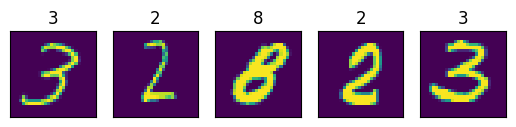

In [13]:
plot_example(X_train, y_train)

## Build Neural Network with PyTorch
Simple, fully connected neural network with one hidden layer. Input layer has 784 dimensions (28x28), hidden layer has 98 (= 784 / 8) and output layer 10 neurons, representing digits 0 - 9.

In [24]:
import torch
from torch import nn
import torch.nn.functional as F

In [25]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [26]:
mnist_dim = X.shape[1]
hidden_dim = int(mnist_dim/8)
output_dim = len(np.unique(mnist.target))

In [27]:
mnist_dim, hidden_dim, output_dim

(784, 98, 10)

A Neural network in PyTorch's framework.

In [28]:
class ClassifierModule(nn.Module):
    def __init__(
            self,
            input_dim=mnist_dim,
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            dropout=0.5,
    ):
        super(ClassifierModule, self).__init__()
        self.dropout = nn.Dropout(dropout)

        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self, X, **kwargs):
        X = F.relu(self.hidden(X))
        X = self.dropout(X)
        X = F.softmax(self.output(X), dim=-1)
        return X

skorch allows to use PyTorch's networks in the SciKit-Learn setting:

In [29]:
from skorch import NeuralNetClassifier

In [30]:
torch.manual_seed(0)

net = NeuralNetClassifier(
    ClassifierModule,
    max_epochs=20,
    lr=0.1,
    device=device,
)

In [19]:
net.fit(X_train, y_train)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.8308       0.8900        0.3968  0.5305
      2        0.4344       0.9109        0.3131  0.4859
      3        0.3644       0.9214        0.2710  0.4864
      4        0.3251       0.9312        0.2407  0.4888
      5        0.2946       0.9374        0.2129  0.6124
      6        0.2726       0.9407        0.2001  0.6032
      7        0.2600       0.9445        0.1883  0.5284
      8        0.2486       0.9476        0.1781  0.5441
      9        0.2337       0.9489        0.1725  0.5497
     10        0.2245       0.9506        0.1623  0.5819
     11        0.2201       0.9542        0.1553  0.5318
     12        0.2061       0.9538        0.1513  0.5335
     13        0.2047       0.9567        0.1446  0.5655
     14        0.2003       0.9586        0.1390  0.6294
     15        0.1920       0.9595        0.1364  0.6111
     16        0.1884       0.9

,module,<class '__mai...sifierModule'>
,criterion,<class 'torch...loss.NLLLoss'>
,train_split,<skorch.datas...t 0x151ca11d0>
,classes,None
,optimizer,<class 'torch.optim.sgd.SGD'>
,lr,0.1
,max_epochs,20
,batch_size,128
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>


## Prediction

In [20]:
from sklearn.metrics import accuracy_score

In [21]:
y_pred = net.predict(X_test)

In [22]:
accuracy_score(y_test, y_pred)

0.9626285714285714

An accuracy of about 96% for a network with only one hidden layer is not too bad.

Let's take a look at some predictions that went wrong:

In [23]:
error_mask = y_pred != y_test

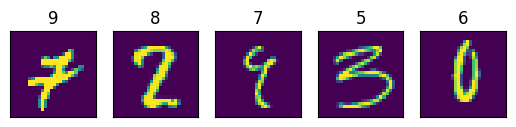

In [24]:
plot_example(X_test[error_mask], y_pred[error_mask])

# Convolutional Network
PyTorch expects a 4 dimensional tensor as input for its 2D convolution layer. The dimensions represent:
* Batch size
* Number of channel
* Height
* Width

As initial batch size the number of examples needs to be provided. MNIST data has only one channel. As stated above, each MNIST vector represents a 28x28 pixel image. Hence, the resulting shape for PyTorch tensor needs to be (x, 1, 28, 28).

In [15]:
XCnn = X.reshape(-1, 1, 28, 28)

In [16]:
XCnn.shape

(70000, 1, 28, 28)

In [17]:
XCnn_train, XCnn_test, y_train, y_test = train_test_split(XCnn, y, test_size=0.25, random_state=42)

In [18]:
XCnn_train.shape, y_train.shape

((52500, 1, 28, 28), (52500,))

In [19]:
class Cnn(nn.Module):
    def __init__(self, dropout=0.5):
        super(Cnn, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv2_drop = nn.Dropout2d(p=dropout)
        self.fc1 = nn.Linear(1600, 100) # 1600 = number channels * width * height
        self.fc2 = nn.Linear(100, 10)
        self.fc1_drop = nn.Dropout(p=dropout)

    def forward(self, x):
        x = torch.relu(F.max_pool2d(self.conv1(x), 2))
        x = torch.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))

        # flatten over channel, height and width = 1600
        x = x.view(-1, x.size(1) * x.size(2) * x.size(3))

        x = torch.relu(self.fc1_drop(self.fc1(x)))
        x = self.fc2(x)
        return x

In [31]:
torch.manual_seed(0)

cnn = NeuralNetClassifier(
    Cnn,
    max_epochs=10,
    lr=0.002,
    optimizer=torch.optim.Adam,
    criterion=nn.CrossEntropyLoss,
    device=device,
)

In [32]:
cnn.fit(XCnn_train, y_train)

  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        0.4444       0.9700        0.0938  13.3231
      2        0.1655       0.9799        0.0666  12.8065
      3        0.1382       0.9810        0.0614  13.0752
      4        0.1141       0.9832        0.0543  13.5321
      5        0.1066       0.9841        0.0507  13.4574
      6        0.0961       0.9864        0.0434  13.3151
      7        0.0921       0.9873        0.0415  13.1419
      8        0.0843       0.9869        0.0402  13.6845
      9        0.0809       0.9872        0.0398  13.1665
     10        0.0794       0.9883        0.0374  13.1496


,module,<class '__main__.Cnn'>
,criterion,<class 'torch...sEntropyLoss'>
,train_split,<skorch.datas...t 0x13e3c2350>
,classes,None
,optimizer,<class 'torch...im.adam.Adam'>
,lr,0.002
,max_epochs,10
,batch_size,128
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>


In [34]:
y_pred_cnn = cnn.predict(XCnn_test)

In [35]:
accuracy_score(y_test, y_pred_cnn)

0.9872571428571428

An accuracy of >98% should suffice for this example!

Let's see how we fare on the examples that went wrong before:

In [36]:
accuracy_score(y_test[error_mask], y_pred_cnn[error_mask])

0.7492354740061162

Over 70% of the previously misclassified images are now correctly identified.

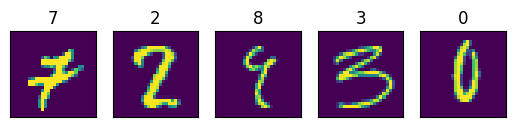

In [37]:
plot_example(X_test[error_mask], y_pred_cnn[error_mask])

### Add Reference: GitHub Link

# Adversarial Attacks on MNIST Dataset (NEW)

### Save Correct Images

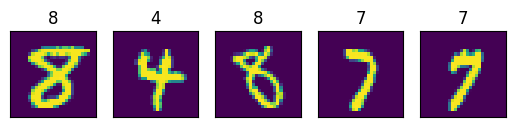

In [38]:
correct_predictions = y_pred_cnn == y_test
plot_example(XCnn_test[correct_predictions], y_pred_cnn[correct_predictions])

In [47]:
# Save first 20 correctly predicted test images for download
import os
from PIL import Image
import numpy as np
import shutil

out_dir = "mnist/original_images"
os.makedirs(out_dir, exist_ok=True)

mask = np.array(correct_predictions)
# Handle boolean mask or indices array
if mask.dtype == bool:
    indices = np.where(mask)[0]
elif mask.ndim == 1 and np.issubdtype(mask.dtype, np.integer):
    # If values are indices (i.e., unique and within range), use them; otherwise interpret as mask
    if mask.max() < X_test.shape[0]:
        indices = mask
    else:
        indices = np.where(mask == 1)[0]
else:
    indices = np.where(mask)[0]

if len(indices) == 0:
    raise ValueError("No correct predictions found in 'correct_predictions'.")

indices = indices[:20]

saved = []
for i, idx in enumerate(indices, start=1):
    img = X_test[idx]
    # If flattened, reshape to 28x28
    if img.ndim == 1:
        img = img.reshape(28, 28)
    # Scale to 0-255 uint8
    if img.dtype.kind == 'f':
        arr = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    else:
        arr = img.astype(np.uint8)
    im = Image.fromarray(arr, mode='L')
    pred = int(y_pred[idx]) if 'y_pred' in globals() else None
    true = int(y_test[idx]) if 'y_test' in globals() else None
    fname = f"{out_dir}/{i:02d}_idx{idx}_true{true}_pred{pred}.png"
    im.save(fname)
    saved.append(fname)

# create zip
zip_name = shutil.make_archive(out_dir, 'zip', out_dir)

print(f"Saved {len(saved)} images to ./{out_dir}/ and created {zip_name}")

Saved 20 images to ./mnist/original_images/ and created /Users/aidanyip/Desktop/University of Glasgow/Year 4/Individual Project/adversarial-images/mnist/original_images.zip


In [40]:
cnn.module_.eval()

Cnn(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv2_drop): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=1600, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
  (fc1_drop): Dropout(p=0.5, inplace=False)
)

### Pixel Attack

In [2]:
import random

def one_pixel_attack(model, image, label, device, num_trials=200):
    """
    image: shape (1, 1, 28, 28), values in [0,1]
    label: int
    """
    model.eval()
    image = image.clone().to(device)
    label = torch.tensor([label]).to(device)

    # Original prediction
    with torch.no_grad():
        orig_pred = model(image).argmax(dim=1).item()

    if orig_pred != label.item():
        return None  # already misclassified

    attacked = image.clone()
    pixel_info = None
    pred = orig_pred

    for _ in range(num_trials):
        attacked = image.clone()

        # Random pixel location
        x = random.randint(0, 27)
        y = random.randint(0, 27)

        # Original pixel value
        orig_val = attacked[0, 0, x, y].item()

        # Maximize difference
        new_value = 1.0 if orig_val < 0.5 else 0.0
        attacked[0, 0, x, y] = new_value

        with torch.no_grad():
            pred = model(attacked).argmax(dim=1).item()

        pixel_info = (x, y, new_value)

        if pred != label.item():
            return attacked.cpu(), pixel_info, pred

    # If no successful attack, return the last attempted attack
    return attacked.cpu(), pixel_info, pred


In [ ]:
successful_attacks = []
failed_attacks = []

for i in range(800):  # try 800 test images
    img = torch.tensor(XCnn_test[i:i+1], dtype=torch.float32)
    label = y_test[i]

    result = one_pixel_attack(
        cnn.module_,
        img,
        label,
        device,
        num_trials=300
    )

    if result is not None:
        attacked_img, pixel_info, new_label = result
        if new_label != label:
            successful_attacks.append((img, attacked_img, label, new_label, pixel_info))
        else:
            failed_attacks.append((img, attacked_img, label, new_label, pixel_info))

    if len(successful_attacks) >= 10:
        break

In [1]:
print(f"Successful pixel attacks: {len(successful_attacks)}")
print(f"Failed pixel attempts: {len(failed_attacks)}")

NameError: name 'successful_attacks' is not defined

In [43]:
def show_attack(original, attacked, true_label, adv_label, pixel_info):
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    ax[0].imshow(original.squeeze(), cmap="gray")
    ax[0].set_title(f"Original: {true_label}")
    ax[0].axis("off")

    ax[1].imshow(attacked.squeeze(), cmap="gray")
    ax[1].set_title(f"Attacked: {adv_label}")
    ax[1].axis("off")

    x, y, v = pixel_info
    plt.suptitle(f"Modified pixel at ({x}, {y}) → {v:.2f}")
    plt.show()

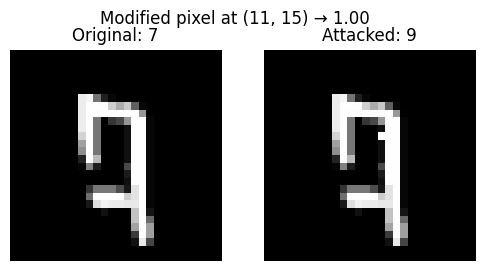

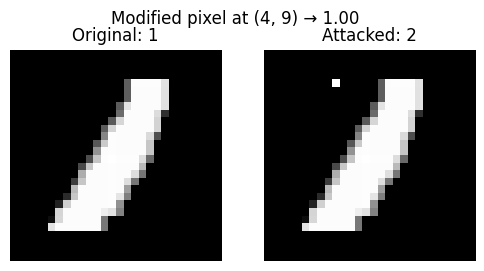

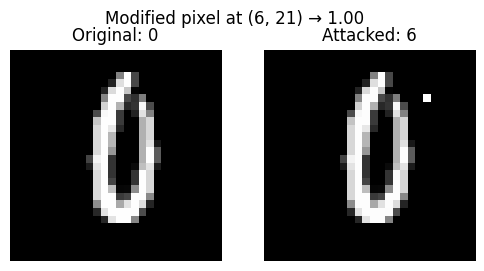

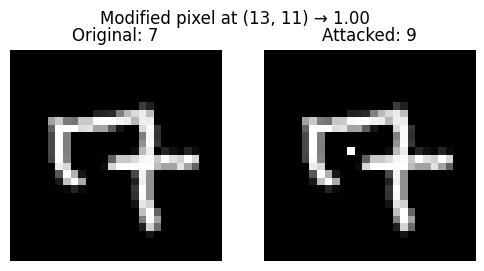

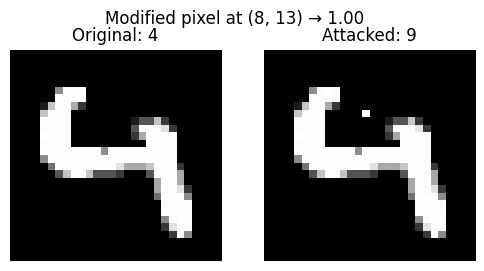

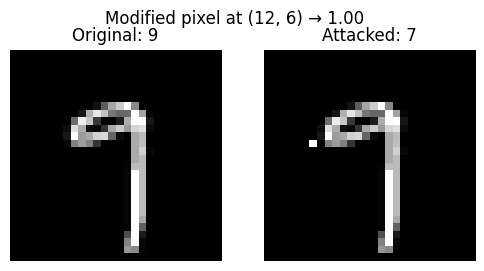

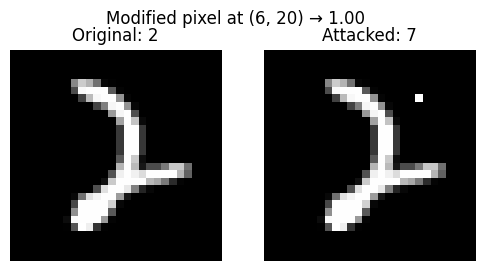

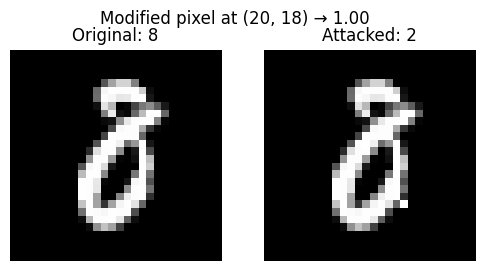

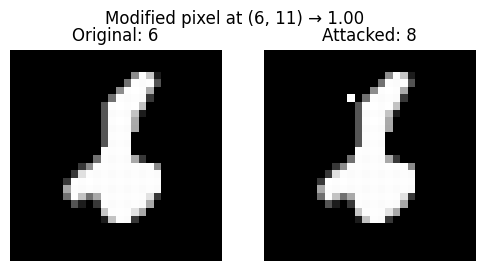

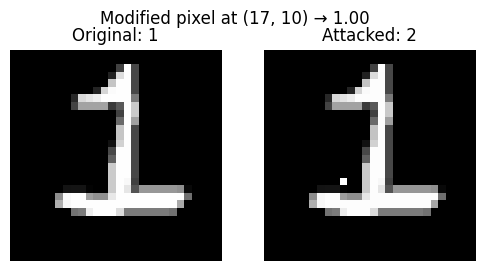

In [44]:
for orig, adv, y_true, y_adv, pixel in successful_attacks:
    show_attack(orig, adv, y_true, y_adv, pixel)

In [46]:
import os
from PIL import Image
import numpy as np

# Create directory to save images
save_dir = "mnist/pixel_attack/successful_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save each attack
for idx, (orig, adv, y_true, y_adv, pixel) in enumerate(successful_attacks):
    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (adv.squeeze().numpy() * 255).astype(np.uint8)
    
    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)
    
    # Save images
    orig_img.save(f"{save_dir}/attack_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir}/attack_{idx}_attacked_pred{y_adv}.png")
    
    print(f"Saved attack {idx}: {y_true} → {y_adv}")

print(f"\nAll {len(successful_attacks)} attacks saved to '{save_dir}' directory")

Saved attack 0: 7 → 9
Saved attack 1: 1 → 2
Saved attack 2: 0 → 6
Saved attack 3: 7 → 9
Saved attack 4: 4 → 9
Saved attack 5: 9 → 7
Saved attack 6: 2 → 7
Saved attack 7: 8 → 2
Saved attack 8: 6 → 8
Saved attack 9: 1 → 2

All 10 attacks saved to 'mnist/pixel_attack/successful_attacks_images' directory


In [55]:
import os
from PIL import Image
import numpy as np

# Create directory to save images
save_dir = "mnist/pixel_attack/failed_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save first 5 failed attacks
for idx, (orig, attacked, y_true, y_pred, pixel) in enumerate(failed_attacks[:10]):
    # Convert tensor to numpy and scale to 0-255
    adv_np = (attacked.squeeze().numpy() * 255).astype(np.uint8)
    
    # Create PIL image
    adv_img = Image.fromarray(adv_np)
    
    # Save image
    adv_img.save(f"{save_dir}/failed_{idx}_true{y_true}_pred{y_pred}.png")
    
    print(f"Saved failed attack {idx}: true {y_true}, pred {y_pred}")

print(f"\nAll {min(10, len(failed_attacks))} failed attacks saved to '{save_dir}' directory")

Saved failed attack 0: true 8, pred 8
Saved failed attack 1: true 4, pred 4
Saved failed attack 2: true 8, pred 8
Saved failed attack 3: true 7, pred 7
Saved failed attack 4: true 7, pred 7
Saved failed attack 5: true 0, pred 0
Saved failed attack 6: true 6, pred 6
Saved failed attack 7: true 2, pred 2
Saved failed attack 8: true 7, pred 7
Saved failed attack 9: true 4, pred 4

All 10 failed attacks saved to 'mnist/pixel_attack/failed_attacks_images' directory


### Rotate

In [ ]:
import random
from torchvision.transforms import functional as TF

def rotate_attack(model, image, label, device, num_trials):
    """
    image: shape (1, 1, 28, 28), values in [0,1]
    label: int
    """
    model.eval()
    image = image.clone().to(device)
    label = torch.tensor([label]).to(device)

    # Original prediction
    with torch.no_grad():
        orig_pred = model(image).argmax(dim=1).item()

    if orig_pred != label.item():
        return None  # already misclassified

    attacked = image.clone()
    rotation_info = None
    pred = orig_pred

    # Try different rotation angles
    angles = [1, 2, 3, 5, 10, 15, -1, -2, -3, -5, -10, -15]
    
    for _ in range(num_trials):
        # Random angle from the list
        angle = random.choice(angles)
        
        # Rotate the image
        rotated = TF.rotate(image, angle, fill=0)
        
        with torch.no_grad():
            pred = model(rotated).argmax(dim=1).item()

        rotation_info = angle

        if pred != label.item():
            return rotated.cpu(), rotation_info, pred

    # If no successful attack, return the last attempted attack
    return rotated.cpu(), rotation_info, pred

In [50]:
successful_rotate_attacks = []
failed_rotate_attacks = []

for i in range(800):  # try 800 test images
    img = torch.tensor(XCnn_test[i:i+1], dtype=torch.float32)
    label = y_test[i]

    result = rotate_attack(
        cnn.module_,
        img,
        label,
        device,
        num_trials=100
    )

    if result is not None:
        attacked_img, rotation_info, new_label = result
        if new_label != label:
            successful_rotate_attacks.append((img, attacked_img, label, new_label, rotation_info))
        else:
            failed_rotate_attacks.append((img, attacked_img, label, new_label, rotation_info))

    if len(successful_rotate_attacks) >= 10:
        break

print(f"Found {len(successful_rotate_attacks)} successful rotate attacks")
print(f"Found {len(failed_rotate_attacks)} failed rotate attempts")

Found 10 successful rotate attacks
Found 222 failed rotate attempts


In [51]:
def show_rotate_attack(original, attacked, true_label, adv_label, rotation_info):
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    ax[0].imshow(original.squeeze(), cmap="gray")
    ax[0].set_title(f"Original: {true_label}")
    ax[0].axis("off")

    ax[1].imshow(attacked.squeeze(), cmap="gray")
    ax[1].set_title(f"Attacked: {adv_label}")
    ax[1].axis("off")

    plt.suptitle(f"Rotated by {rotation_info}°")
    plt.show()

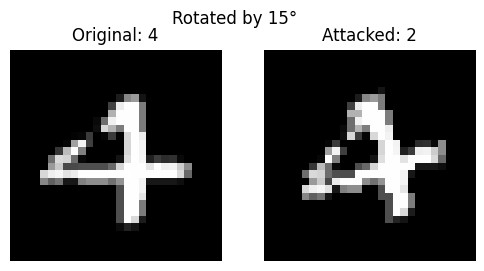

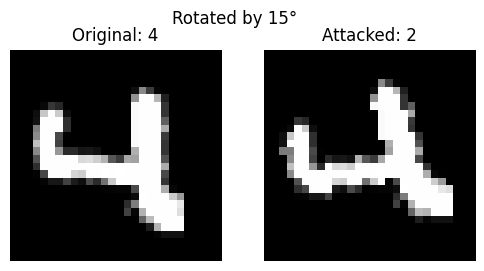

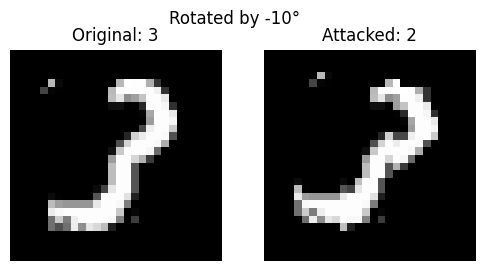

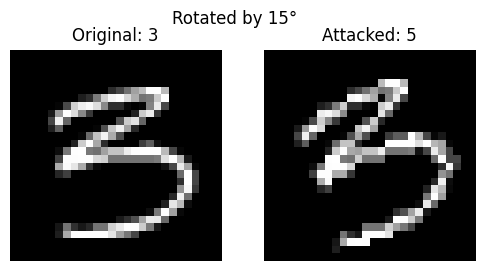

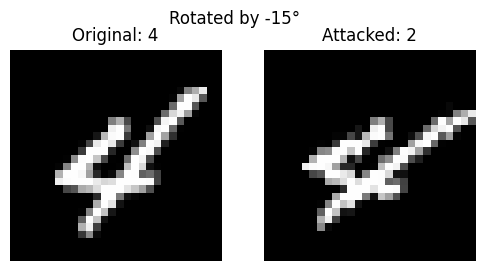

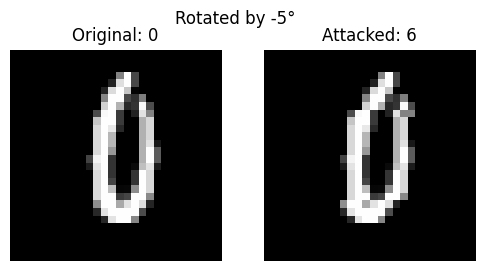

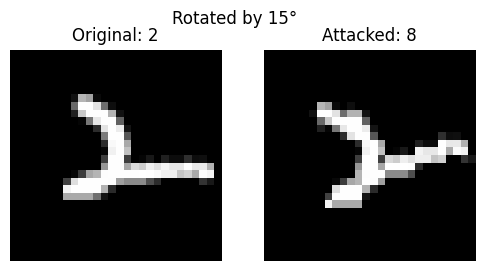

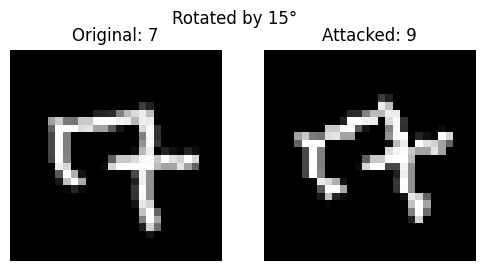

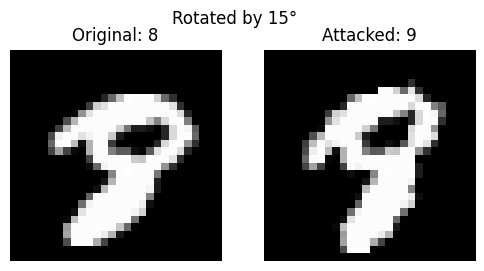

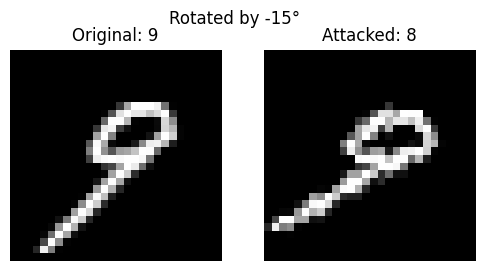

In [52]:
for orig, adv, y_true, y_adv, rotation in successful_rotate_attacks:
    show_rotate_attack(orig, adv, y_true, y_adv, rotation)

In [53]:
import os
from PIL import Image
import numpy as np

# Create directory to save rotate attack images
save_dir = "mnist/rotate/successful_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save each successful rotate attack
for idx, (orig, adv, y_true, y_adv, rotation) in enumerate(successful_rotate_attacks):
    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (adv.squeeze().numpy() * 255).astype(np.uint8)
    
    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)
    
    # Save images
    orig_img.save(f"{save_dir}/rotate_attack_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir}/rotate_attack_{idx}_attacked_pred{y_adv}_rot{rotation}deg.png")
    
    print(f"Saved rotate attack {idx}: {y_true} → {y_adv} (rotated {rotation}°)")

print(f"\nAll {len(successful_rotate_attacks)} rotate attacks saved to '{save_dir}' directory")

Saved rotate attack 0: 4 → 2 (rotated 15°)
Saved rotate attack 1: 4 → 2 (rotated 15°)
Saved rotate attack 2: 3 → 2 (rotated -10°)
Saved rotate attack 3: 3 → 5 (rotated 15°)
Saved rotate attack 4: 4 → 2 (rotated -15°)
Saved rotate attack 5: 0 → 6 (rotated -5°)
Saved rotate attack 6: 2 → 8 (rotated 15°)
Saved rotate attack 7: 7 → 9 (rotated 15°)
Saved rotate attack 8: 8 → 9 (rotated 15°)
Saved rotate attack 9: 9 → 8 (rotated -15°)

All 10 rotate attacks saved to 'mnist/rotate/successful_attacks_images' directory


In [57]:
import os
from PIL import Image
import numpy as np

# Create directory to save failed rotate attack images
save_dir = "mnist/rotate/failed_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save first 5 failed rotate attacks
for idx, (orig, attacked, y_true, y_pred, rotation) in enumerate(failed_rotate_attacks[:10]):
    # Convert tensor to numpy and scale to 0-255
    adv_np = (attacked.squeeze().numpy() * 255).astype(np.uint8)
    
    # Create PIL image
    adv_img = Image.fromarray(adv_np)
    
    # Save image
    adv_img.save(f"{save_dir}/failed_rotate_{idx}_true{y_true}_pred{y_pred}_rot{rotation}deg.png")
    
    print(f"Saved failed rotate attack {idx}: true {y_true}, pred {y_pred}, rotated {rotation}°")

print(f"\nAll {min(10, len(failed_rotate_attacks))} failed rotate attacks saved to '{save_dir}' directory")

Saved failed rotate attack 0: true 8, pred 8, rotated 2°
Saved failed rotate attack 1: true 4, pred 4, rotated -1°
Saved failed rotate attack 2: true 8, pred 8, rotated 5°
Saved failed rotate attack 3: true 7, pred 7, rotated -5°
Saved failed rotate attack 4: true 7, pred 7, rotated 5°
Saved failed rotate attack 5: true 0, pred 0, rotated -1°
Saved failed rotate attack 6: true 6, pred 6, rotated 2°
Saved failed rotate attack 7: true 2, pred 2, rotated 2°
Saved failed rotate attack 8: true 7, pred 7, rotated 15°
Saved failed rotate attack 9: true 3, pred 3, rotated -15°

All 10 failed rotate attacks saved to 'mnist/rotate/failed_attacks_images' directory


### Shift Attack

In [58]:
import random
from torchvision.transforms import functional as TF

def shift_attack(model, image, label, device, num_trials=50):
    """
    image: shape (1, 1, 28, 28), values in [0,1]
    label: int
    """
    model.eval()
    image = image.clone().to(device)
    label = torch.tensor([label]).to(device)

    # Original prediction
    with torch.no_grad():
        orig_pred = model(image).argmax(dim=1).item()

    if orig_pred != label.item():
        return None  # already misclassified

    attacked = image.clone()
    shift_info = None
    pred = orig_pred

    # Try different shift amounts
    shifts = [1, 2, 3, 4, 5, -1, -2, -3, -4, -5]
    
    for _ in range(num_trials):
        # Random shifts in x and y directions
        dx = random.choice(shifts)
        dy = random.choice(shifts)
        
        # Shift the image using affine transform
        shifted = TF.affine(image, angle=0, translate=(dx, dy), scale=1.0, shear=0, fill=0)
        
        with torch.no_grad():
            pred = model(shifted).argmax(dim=1).item()

        shift_info = (dx, dy)

        if pred != label.item():
            return shifted.cpu(), shift_info, pred

    # If no successful attack, return the last attempted attack
    return shifted.cpu(), shift_info, pred

In [ ]:
successful_shift_attacks = []
failed_shift_attacks = []

for i in range(800):  # try 800 test images
    img = torch.tensor(XCnn_test[i:i+1], dtype=torch.float32)
    label = y_test[i]

    result = shift_attack(
        cnn.module_,
        img,
        label,
        device,
        num_trials=100
    )

    if result is not None:
        attacked_img, shift_info, new_label = result
        if new_label != label:
            successful_shift_attacks.append((img, attacked_img, label, new_label, shift_info))
        else:
            failed_shift_attacks.append((img, attacked_img, label, new_label, shift_info))

    if len(successful_shift_attacks) >= 10:
        break

print(f"Found {len(successful_shift_attacks)} successful shift attacks")
print(f"Found {len(failed_shift_attacks)} failed shift attempts")

Found 10 successful shift attacks
Found 0 failed shift attempts


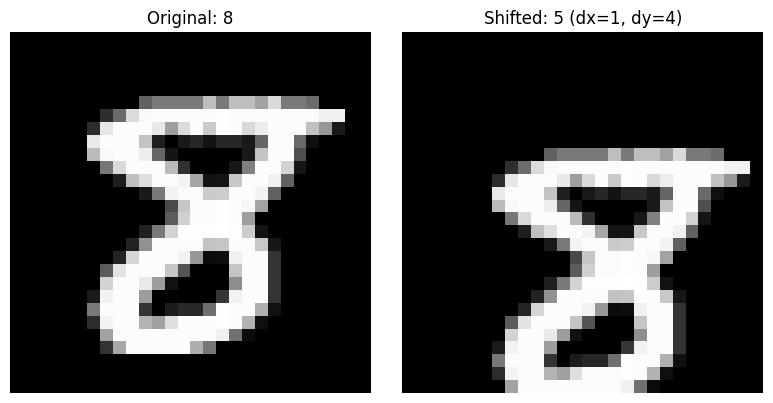

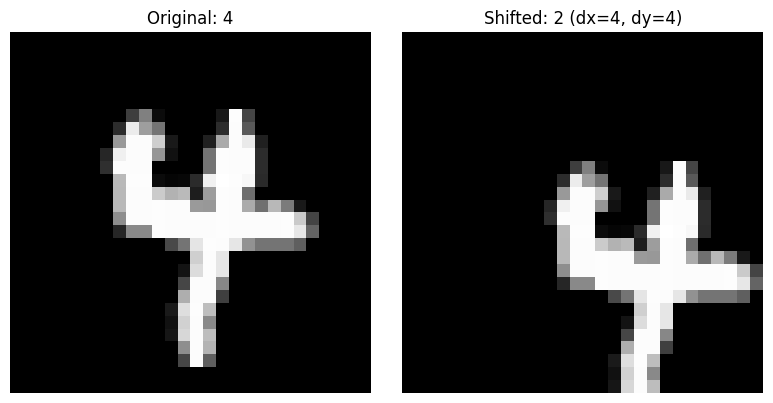

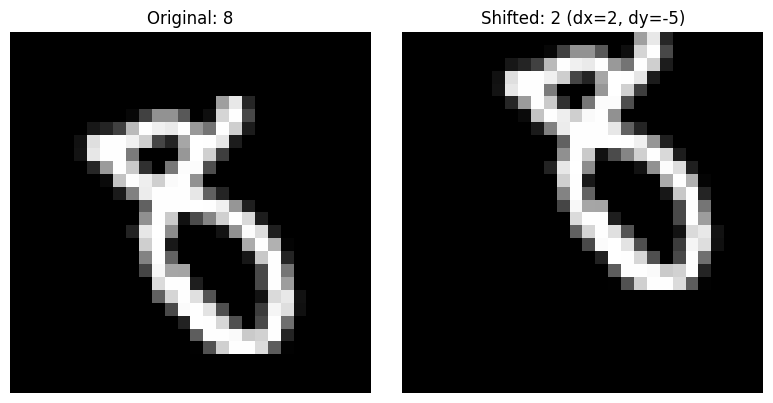

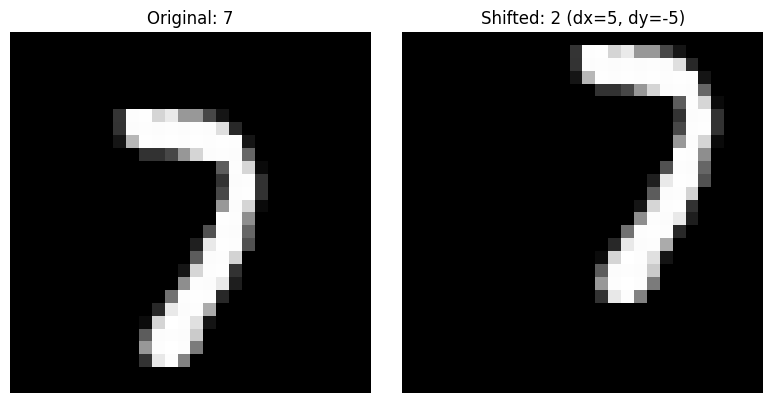

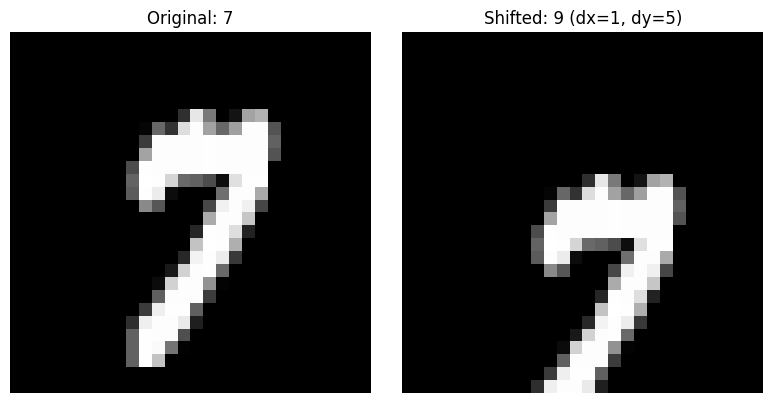

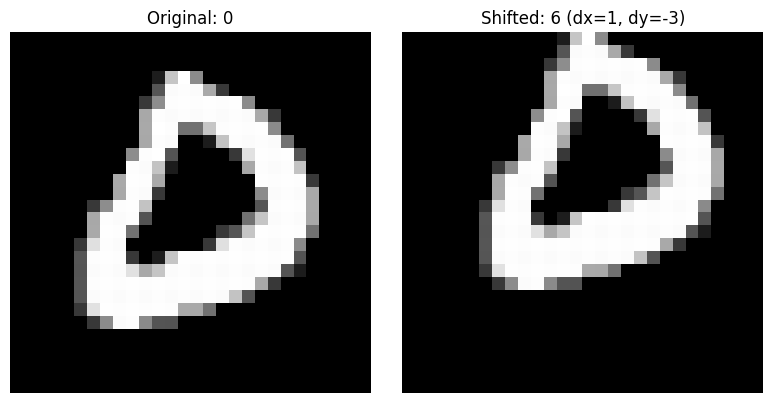

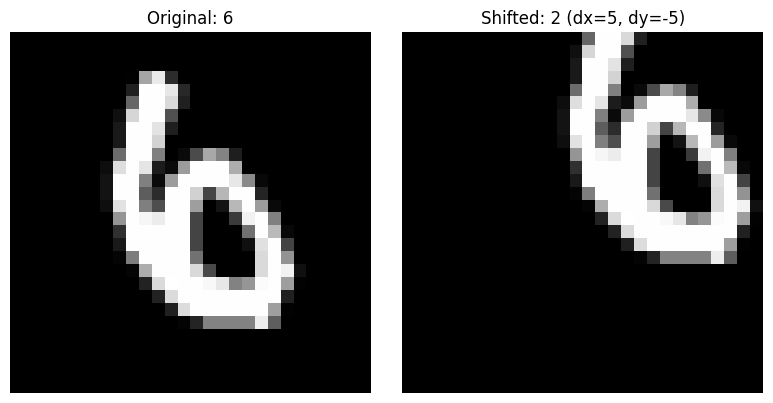

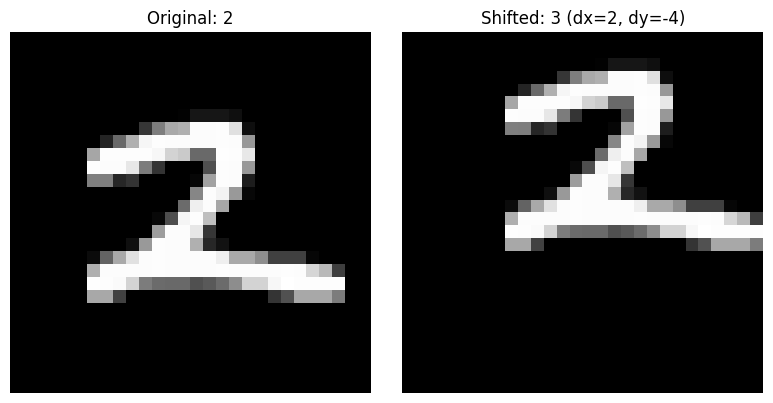

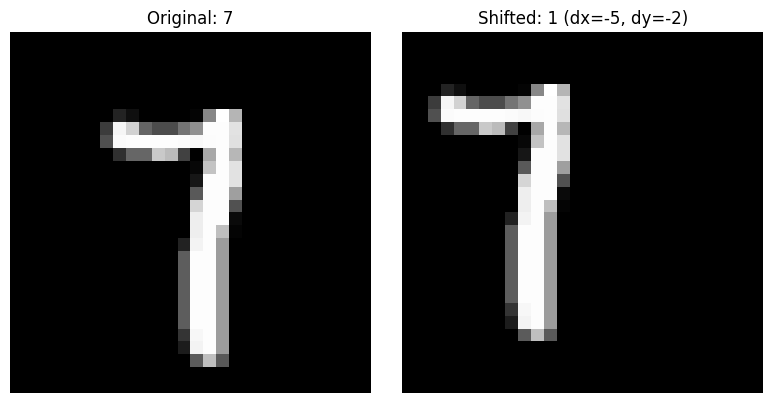

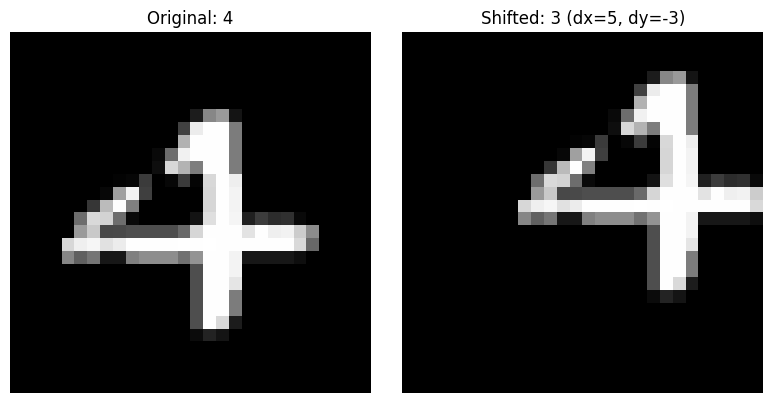

In [60]:
def show_shift_attack(original, attacked, true_label, adv_label, shift_info):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    # Original image
    axes[0].imshow(original.squeeze(), cmap='gray')
    axes[0].set_title(f'Original: {true_label}')
    axes[0].axis('off')
    
    # Attacked image
    axes[1].imshow(attacked.squeeze(), cmap='gray')
    axes[1].set_title(f'Shifted: {adv_label} (dx={shift_info[0]}, dy={shift_info[1]})')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Display successful shift attacks
for orig, adv, y_true, y_adv, shift in successful_shift_attacks:
    show_shift_attack(orig, adv, y_true, y_adv, shift)

In [61]:
import os
from PIL import Image

# Create directory to save shift attack images
save_dir = "mnist/shift_attack/successful_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save each successful shift attack
for idx, (orig, adv, y_true, y_adv, shift) in enumerate(successful_shift_attacks):
    dx, dy = shift
    
    # Convert to PIL images
    orig_img = Image.fromarray((orig.squeeze().numpy() * 255).astype(np.uint8), mode='L')
    adv_img = Image.fromarray((adv.squeeze().numpy() * 255).astype(np.uint8), mode='L')
    
    # Save images
    orig_img.save(f"{save_dir}/shift_attack_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir}/shift_attack_{idx}_attacked_pred{y_adv}_dx{dx}_dy{dy}.png")
    
    print(f"Saved shift attack {idx}: {y_true} → {y_adv} (shifted dx={dx}, dy={dy})")

print(f"\nAll {len(successful_shift_attacks)} shift attacks saved to '{save_dir}' directory")

Saved shift attack 0: 8 → 5 (shifted dx=1, dy=4)
Saved shift attack 1: 4 → 2 (shifted dx=4, dy=4)
Saved shift attack 2: 8 → 2 (shifted dx=2, dy=-5)
Saved shift attack 3: 7 → 2 (shifted dx=5, dy=-5)
Saved shift attack 4: 7 → 9 (shifted dx=1, dy=5)
Saved shift attack 5: 0 → 6 (shifted dx=1, dy=-3)
Saved shift attack 6: 6 → 2 (shifted dx=5, dy=-5)
Saved shift attack 7: 2 → 3 (shifted dx=2, dy=-4)
Saved shift attack 8: 7 → 1 (shifted dx=-5, dy=-2)
Saved shift attack 9: 4 → 3 (shifted dx=5, dy=-3)

All 10 shift attacks saved to 'mnist/shift_attack/successful_attacks_images' directory


In [62]:
# Create directory to save failed shift attack images
save_dir_failed = "mnist/shift_attack/failed_attacks_images"
os.makedirs(save_dir_failed, exist_ok=True)

# Save first 5 failed shift attacks
for idx, (orig, attacked, y_true, y_pred, shift) in enumerate(failed_shift_attacks[:10]):
    dx, dy = shift
    
    # Convert to PIL images
    orig_img = Image.fromarray((orig.squeeze().numpy() * 255).astype(np.uint8), mode='L')
    adv_img = Image.fromarray((attacked.squeeze().numpy() * 255).astype(np.uint8), mode='L')
    
    # Save images
    orig_img.save(f"{save_dir_failed}/failed_shift_attack_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir_failed}/failed_shift_attack_{idx}_attacked_pred{y_pred}_dx{dx}_dy{dy}.png")
    
    print(f"Saved failed shift attack {idx}: true {y_true}, pred {y_pred}, shifted dx={dx}, dy={dy}")

print(f"\nAll {min(10, len(failed_shift_attacks))} failed shift attacks saved to '{save_dir_failed}' directory")


All 0 failed shift attacks saved to 'shift_attack/failed_attacks_images' directory


### Blur Attack
Gaussian blur with random kernel size and sigma

In [63]:
import random
from torchvision.transforms import functional as TF

def blur_attack(model, image, label, device, num_trials=50):
    """
    image: shape (1, 1, 28, 28), values in [0,1]
    label: int
    """
    model.eval()
    image = image.clone().to(device)
    label = torch.tensor([label]).to(device)

    # Original prediction
    with torch.no_grad():
        orig_pred = model(image).argmax(dim=1).item()

    if orig_pred != label.item():
        return None  # already misclassified

    blurred = image.clone()
    blur_info = None
    pred = orig_pred

    kernel_sizes = [3, 5, 7]
    sigmas = [0.5, 1.0, 1.5, 2.0]

    for _ in range(num_trials):
        k = random.choice(kernel_sizes)
        sigma = random.choice(sigmas)

        blurred = TF.gaussian_blur(image, kernel_size=[k, k], sigma=[sigma, sigma])

        with torch.no_grad():
            pred = model(blurred).argmax(dim=1).item()

        blur_info = (k, sigma)

        if pred != label.item():
            return blurred.cpu(), blur_info, pred

    # If no successful attack, return the last attempted attack
    return blurred.cpu(), blur_info, pred

In [64]:
successful_blur_attacks = []
failed_blur_attacks = []

for i in range(800):  # try 800 test images
    img = torch.tensor(XCnn_test[i:i+1], dtype=torch.float32)
    label = y_test[i]

    result = blur_attack(
        cnn.module_,
        img,
        label,
        device,
        num_trials=100,
    )

    if result is not None:
        attacked_img, blur_info, new_label = result
        if new_label != label:
            successful_blur_attacks.append((img, attacked_img, label, new_label, blur_info))
        else:
            failed_blur_attacks.append((img, attacked_img, label, new_label, blur_info))

    if len(successful_blur_attacks) >= 10:
        break

print(f"Found {len(successful_blur_attacks)} successful blur attacks")
print(f"Found {len(failed_blur_attacks)} failed blur attempts")

Found 10 successful blur attacks
Found 89 failed blur attempts


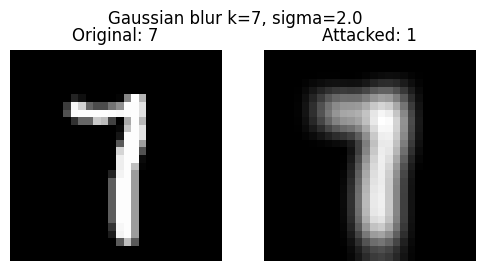

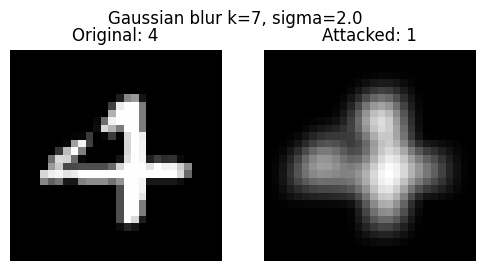

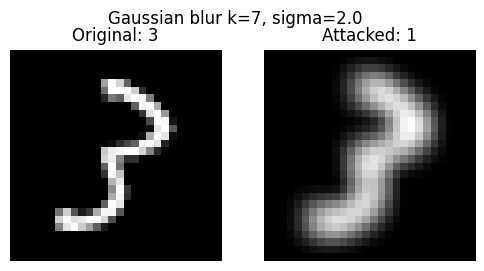

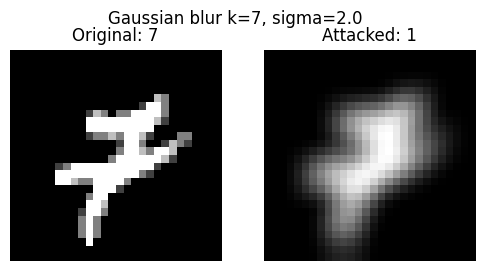

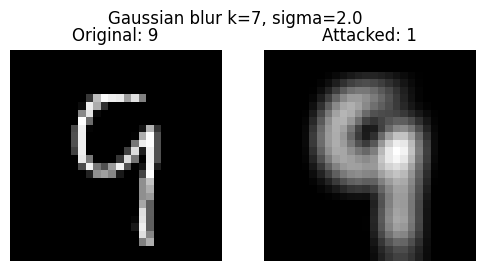

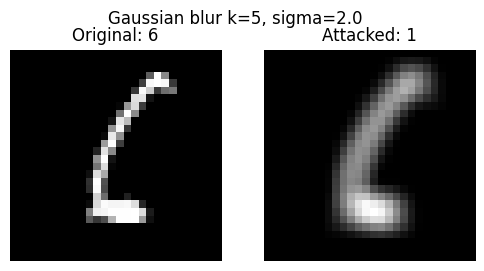

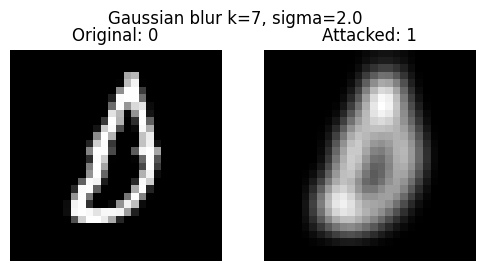

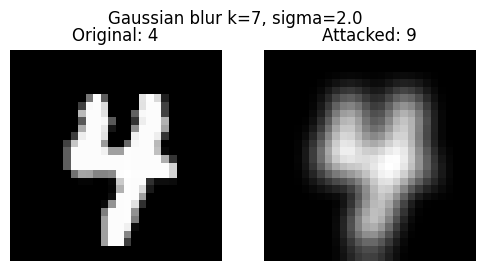

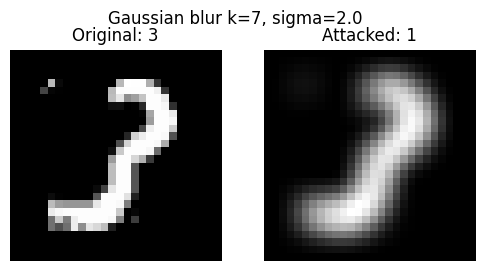

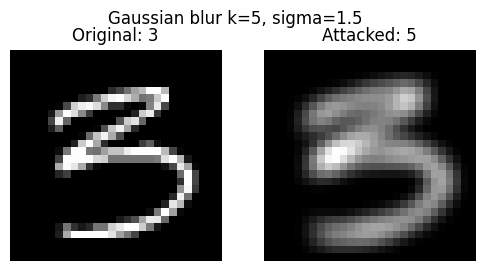

In [65]:
def show_blur_attack(original, attacked, true_label, adv_label, blur_info):
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    ax[0].imshow(original.squeeze(), cmap="gray")
    ax[0].set_title(f"Original: {true_label}")
    ax[0].axis("off")

    ax[1].imshow(attacked.squeeze(), cmap="gray")
    ax[1].set_title(f"Attacked: {adv_label}")
    ax[1].axis("off")

    kernel, sigma = blur_info
    plt.suptitle(f"Gaussian blur k={kernel}, sigma={sigma}")
    plt.show()

for orig, adv, y_true, y_adv, blur in successful_blur_attacks:
    show_blur_attack(orig, adv, y_true, y_adv, blur)

In [66]:
import os
from PIL import Image
import numpy as np

# Create directory to save blur attack images
save_dir = "mnist/blur_attack/successful_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save each successful blur attack
for idx, (orig, adv, y_true, y_adv, blur) in enumerate(successful_blur_attacks):
    kernel, sigma = blur

    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (adv.squeeze().numpy() * 255).astype(np.uint8)

    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    # Save images
    orig_img.save(f"{save_dir}/blur_attack_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir}/blur_attack_{idx}_attacked_pred{y_adv}_k{kernel}_s{sigma}.png")

    print(f"Saved blur attack {idx}: {y_true} → {y_adv} (k={kernel}, sigma={sigma})")

print(f"\nAll {len(successful_blur_attacks)} blur attacks saved to '{save_dir}' directory")

Saved blur attack 0: 7 → 1 (k=7, sigma=2.0)
Saved blur attack 1: 4 → 1 (k=7, sigma=2.0)
Saved blur attack 2: 3 → 1 (k=7, sigma=2.0)
Saved blur attack 3: 7 → 1 (k=7, sigma=2.0)
Saved blur attack 4: 9 → 1 (k=7, sigma=2.0)
Saved blur attack 5: 6 → 1 (k=5, sigma=2.0)
Saved blur attack 6: 0 → 1 (k=7, sigma=2.0)
Saved blur attack 7: 4 → 9 (k=7, sigma=2.0)
Saved blur attack 8: 3 → 1 (k=7, sigma=2.0)
Saved blur attack 9: 3 → 5 (k=5, sigma=1.5)

All 10 blur attacks saved to 'mnist/blur_attack/successful_attacks_images' directory


In [67]:
# Create directory to save failed blur attack images
save_dir_failed = "mnist/blur_attack/failed_attacks_images"
os.makedirs(save_dir_failed, exist_ok=True)

# Save first 5 failed blur attacks
for idx, (orig, attacked, y_true, y_pred, blur) in enumerate(failed_blur_attacks[:10]):
    kernel, sigma = blur

    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (attacked.squeeze().numpy() * 255).astype(np.uint8)

    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    # Save images
    orig_img.save(f"{save_dir_failed}/failed_blur_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir_failed}/failed_blur_{idx}_attacked_pred{y_pred}_k{kernel}_s{sigma}.png")

    print(f"Saved failed blur attack {idx}: true {y_true}, pred {y_pred}, k={kernel}, sigma={sigma}")

print(f"\nAll {min(10, len(failed_blur_attacks))} failed blur attacks saved to '{save_dir_failed}' directory")

Saved failed blur attack 0: true 8, pred 8, k=3, sigma=1.5
Saved failed blur attack 1: true 4, pred 4, k=7, sigma=0.5
Saved failed blur attack 2: true 8, pred 8, k=7, sigma=1.5
Saved failed blur attack 3: true 7, pred 7, k=5, sigma=2.0
Saved failed blur attack 4: true 7, pred 7, k=7, sigma=0.5
Saved failed blur attack 5: true 0, pred 0, k=3, sigma=1.5
Saved failed blur attack 6: true 6, pred 6, k=5, sigma=1.0
Saved failed blur attack 7: true 2, pred 2, k=3, sigma=0.5
Saved failed blur attack 8: true 9, pred 9, k=3, sigma=2.0
Saved failed blur attack 9: true 9, pred 9, k=5, sigma=0.5

All 10 failed blur attacks saved to 'mnist/blur_attack/failed_attacks_images' directory


### Random Noise Attack

In [68]:
import random

def random_noise_attack(model, image, label, device, num_trials=50):
    """
    image: shape (1, 1, 28, 28), values in [0,1]
    label: int
    """
    model.eval()
    image = image.clone().to(device)
    label = torch.tensor([label]).to(device)

    # Original prediction
    with torch.no_grad():
        orig_pred = model(image).argmax(dim=1).item()

    if orig_pred != label.item():
        return None  # already misclassified

    attacked = image.clone()
    sigma_used = None
    pred = orig_pred

    sigmas = [0.05, 0.1, 0.15, 0.2, 0.25]

    for _ in range(num_trials):
        sigma = random.choice(sigmas)
        noise = torch.randn_like(image) * sigma
        attacked = torch.clamp(image + noise, 0.0, 1.0)

        with torch.no_grad():
            pred = model(attacked).argmax(dim=1).item()

        sigma_used = sigma

        if pred != label.item():
            return attacked.cpu(), sigma_used, pred

    # If no successful attack, return the last attempted attack
    return attacked.cpu(), sigma_used, pred

In [69]:
successful_noise_attacks = []
failed_noise_attacks = []

for i in range(800):  # try 800 test images
    img = torch.tensor(XCnn_test[i:i+1], dtype=torch.float32)
    label = y_test[i]

    result = random_noise_attack(
        cnn.module_,
        img,
        label,
        device,
        num_trials=100,
    )

    if result is not None:
        attacked_img, sigma_used, new_label = result
        if new_label != label:
            successful_noise_attacks.append((img, attacked_img, label, new_label, sigma_used))
        else:
            failed_noise_attacks.append((img, attacked_img, label, new_label, sigma_used))

    if len(successful_noise_attacks) >= 10:
        break

print(f"Found {len(successful_noise_attacks)} successful noise attacks")
print(f"Found {len(failed_noise_attacks)} failed noise attempts")

Found 10 successful noise attacks
Found 115 failed noise attempts


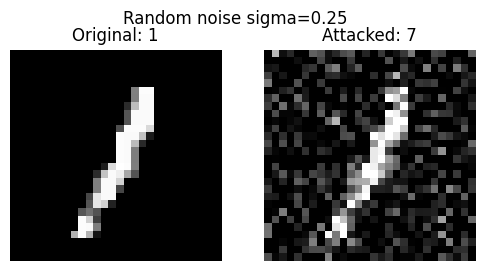

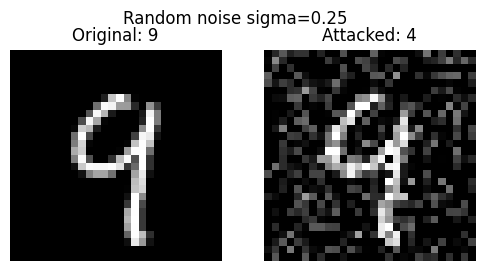

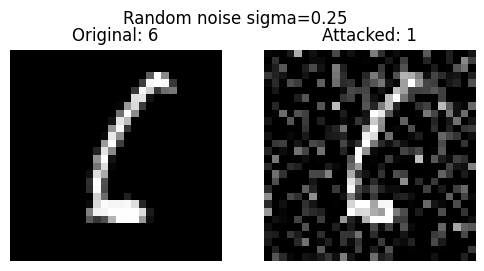

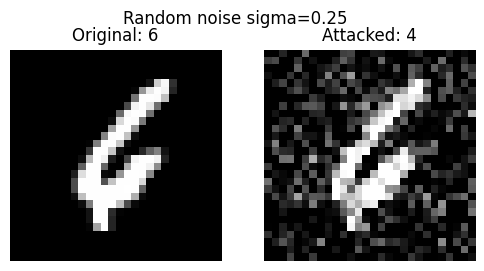

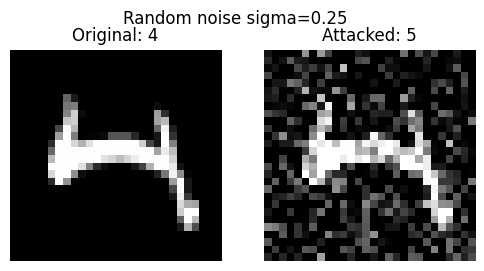

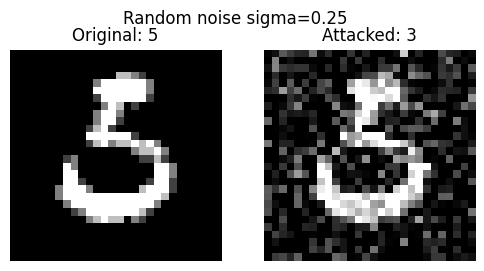

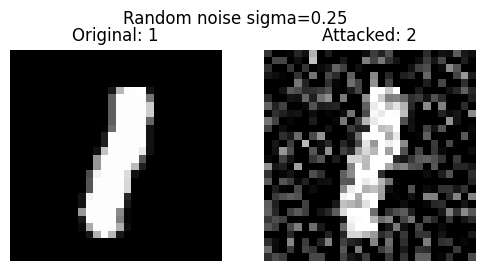

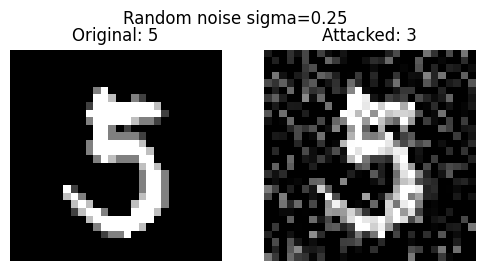

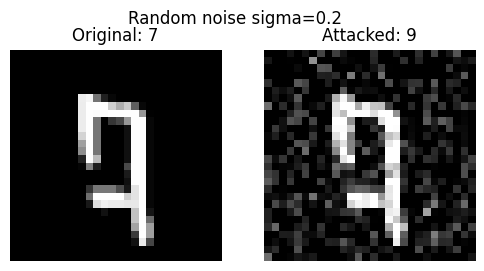

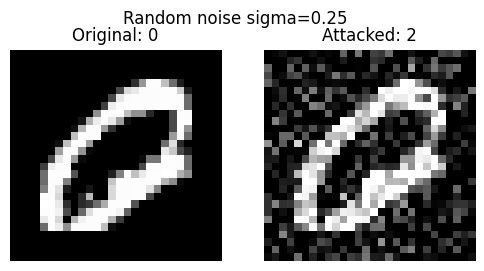

In [70]:
def show_noise_attack(original, attacked, true_label, adv_label, sigma_used):
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    ax[0].imshow(original.squeeze(), cmap="gray")
    ax[0].set_title(f"Original: {true_label}")
    ax[0].axis("off")

    ax[1].imshow(attacked.squeeze(), cmap="gray")
    ax[1].set_title(f"Attacked: {adv_label}")
    ax[1].axis("off")

    plt.suptitle(f"Random noise sigma={sigma_used}")
    plt.show()

for orig, adv, y_true, y_adv, sigma in successful_noise_attacks:
    show_noise_attack(orig, adv, y_true, y_adv, sigma)

In [71]:
import os
from PIL import Image
import numpy as np

# Create directory to save noise attack images
save_dir = "mnist/noise_attack/successful_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save first 5 successful noise attacks
for idx, (orig, adv, y_true, y_adv, sigma) in enumerate(successful_noise_attacks[:10]):
    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (adv.squeeze().numpy() * 255).astype(np.uint8)

    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    # Save images
    orig_img.save(f"{save_dir}/noise_attack_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir}/noise_attack_{idx}_attacked_pred{y_adv}_sigma{sigma}.png")

    print(f"Saved noise attack {idx}: {y_true} -> {y_adv} (sigma={sigma})")

print(f"\nAll {min(10, len(successful_noise_attacks))} successful noise attacks saved to '{save_dir}' directory")

Saved noise attack 0: 1 -> 7 (sigma=0.25)
Saved noise attack 1: 9 -> 4 (sigma=0.25)
Saved noise attack 2: 6 -> 1 (sigma=0.25)
Saved noise attack 3: 6 -> 4 (sigma=0.25)
Saved noise attack 4: 4 -> 5 (sigma=0.25)
Saved noise attack 5: 5 -> 3 (sigma=0.25)
Saved noise attack 6: 1 -> 2 (sigma=0.25)
Saved noise attack 7: 5 -> 3 (sigma=0.25)
Saved noise attack 8: 7 -> 9 (sigma=0.2)
Saved noise attack 9: 0 -> 2 (sigma=0.25)

All 10 successful noise attacks saved to 'mnist/noise_attack/successful_attacks_images' directory


In [72]:
# Create directory to save failed noise attack images
save_dir_failed = "mnist/noise_attack/failed_attacks_images"
os.makedirs(save_dir_failed, exist_ok=True)

# Save first 5 failed noise attacks
for idx, (orig, attacked, y_true, y_pred, sigma) in enumerate(failed_noise_attacks[:10]):
    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (attacked.squeeze().numpy() * 255).astype(np.uint8)

    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    # Save images
    orig_img.save(f"{save_dir_failed}/failed_noise_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir_failed}/failed_noise_{idx}_attacked_pred{y_pred}_sigma{sigma}.png")

    print(f"Saved failed noise attack {idx}: true {y_true}, pred {y_pred}, sigma={sigma}")

print(f"\nAll {min(10, len(failed_noise_attacks))} failed noise attacks saved to '{save_dir_failed}' directory")

Saved failed noise attack 0: true 8, pred 8, sigma=0.15
Saved failed noise attack 1: true 4, pred 4, sigma=0.1
Saved failed noise attack 2: true 8, pred 8, sigma=0.25
Saved failed noise attack 3: true 7, pred 7, sigma=0.2
Saved failed noise attack 4: true 7, pred 7, sigma=0.05
Saved failed noise attack 5: true 0, pred 0, sigma=0.1
Saved failed noise attack 6: true 6, pred 6, sigma=0.05
Saved failed noise attack 7: true 2, pred 2, sigma=0.2
Saved failed noise attack 8: true 7, pred 7, sigma=0.15
Saved failed noise attack 9: true 4, pred 4, sigma=0.25

All 10 failed noise attacks saved to 'mnist/noise_attack/failed_attacks_images' directory


### Adversarial Patches
Self made

In [73]:
import os
import random
from PIL import Image
import numpy as np

patch_path = "mnist/patch.png"
if not os.path.isfile(patch_path):
    raise FileNotFoundError(f"Patch image not found: {patch_path}")

patch_size = 8
patch_img = Image.open(patch_path).convert("L").resize((patch_size, patch_size))
patch_arr = np.array(patch_img, dtype=np.float32) / 255.0
patch_tensor = torch.from_numpy(patch_arr).unsqueeze(0).unsqueeze(0)

def patch_attack(model, image, label, device, patch, num_trials=50):
    """
    image: shape (1, 1, 28, 28), values in [0,1]
    label: int
    """
    model.eval()
    image = image.clone().to(device)
    label = torch.tensor([label]).to(device)
    patch = patch.to(device)

    # Original prediction
    with torch.no_grad():
        orig_pred = model(image).argmax(dim=1).item()

    if orig_pred != label.item():
        return None  # already misclassified

    attacked = image.clone()
    patch_info = None
    pred = orig_pred

    ph, pw = patch.shape[-2], patch.shape[-1]

    for _ in range(num_trials):
        attacked = image.clone()

        x = random.randint(0, 28 - ph)
        y = random.randint(0, 28 - pw)

        attacked[0, 0, x:x + ph, y:y + pw] = patch[0, 0]

        with torch.no_grad():
            pred = model(attacked).argmax(dim=1).item()

        patch_info = (x, y, ph, pw)

        if pred != label.item():
            return attacked.cpu(), patch_info, pred

    # If no successful attack, return the last attempted attack
    return attacked.cpu(), patch_info, pred

In [74]:
successful_patch_attacks = []
failed_patch_attacks = []

for i in range(800):  # try 800 test images
    img = torch.tensor(XCnn_test[i:i+1], dtype=torch.float32)
    label = y_test[i]

    result = patch_attack(
        cnn.module_,
        img,
        label,
        device,
        patch_tensor,
        num_trials=100,
    )

    if result is not None:
        attacked_img, patch_info, new_label = result
        if new_label != label:
            successful_patch_attacks.append((img, attacked_img, label, new_label, patch_info))
        else:
            failed_patch_attacks.append((img, attacked_img, label, new_label, patch_info))

    if len(successful_patch_attacks) >= 10:
        break

print(f"Found {len(successful_patch_attacks)} successful patch attacks")
print(f"Found {len(failed_patch_attacks)} failed patch attempts")

Found 10 successful patch attacks
Found 3 failed patch attempts


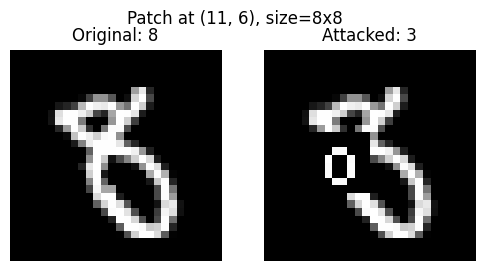

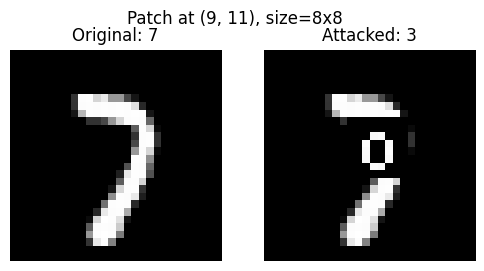

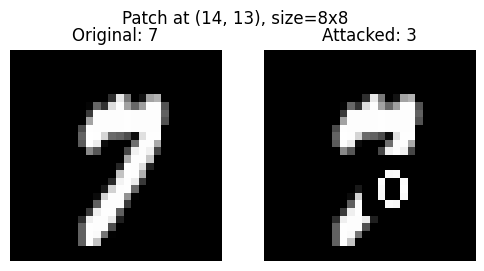

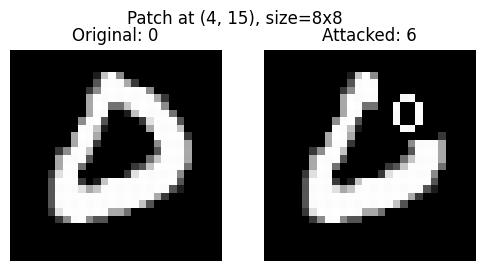

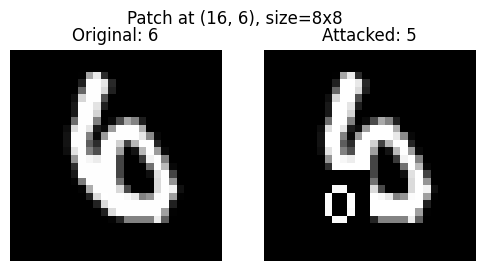

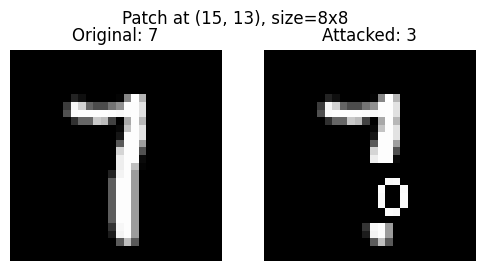

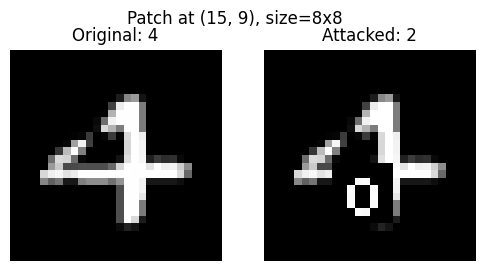

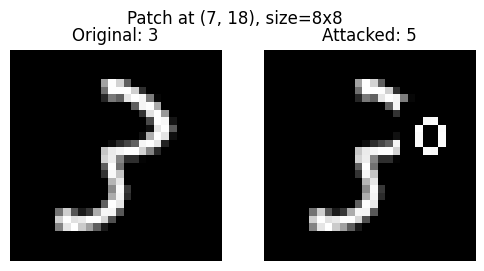

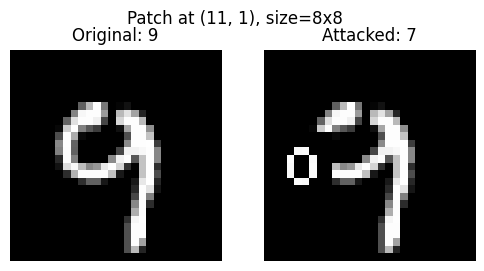

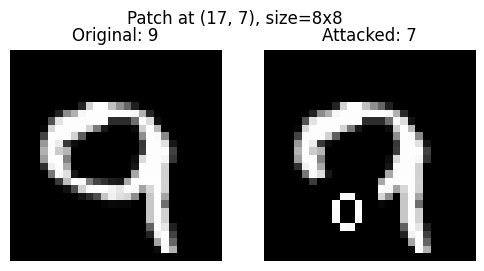

In [75]:
def show_patch_attack(original, attacked, true_label, adv_label, patch_info):
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    ax[0].imshow(original.squeeze(), cmap="gray")
    ax[0].set_title(f"Original: {true_label}")
    ax[0].axis("off")

    ax[1].imshow(attacked.squeeze(), cmap="gray")
    ax[1].set_title(f"Attacked: {adv_label}")
    ax[1].axis("off")

    x, y, ph, pw = patch_info
    plt.suptitle(f"Patch at ({x}, {y}), size={ph}x{pw}")
    plt.show()

for orig, adv, y_true, y_adv, patch in successful_patch_attacks:
    show_patch_attack(orig, adv, y_true, y_adv, patch)

In [76]:
import os
from PIL import Image
import numpy as np

# Create directory to save patch attack images
save_dir = "mnist/patch_attack/successful_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save each successful patch attack
for idx, (orig, adv, y_true, y_adv, patch) in enumerate(successful_patch_attacks):
    x, y, ph, pw = patch

    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (adv.squeeze().numpy() * 255).astype(np.uint8)

    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    # Save images
    orig_img.save(f"{save_dir}/patch_attack_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir}/patch_attack_{idx}_attacked_pred{y_adv}_x{x}_y{y}_h{ph}_w{pw}.png")

    print(f"Saved patch attack {idx}: {y_true} → {y_adv} (x={x}, y={y}, h={ph}, w={pw})")

print(f"\nAll {len(successful_patch_attacks)} patch attacks saved to '{save_dir}' directory")

Saved patch attack 0: 8 → 3 (x=11, y=6, h=8, w=8)
Saved patch attack 1: 7 → 3 (x=9, y=11, h=8, w=8)
Saved patch attack 2: 7 → 3 (x=14, y=13, h=8, w=8)
Saved patch attack 3: 0 → 6 (x=4, y=15, h=8, w=8)
Saved patch attack 4: 6 → 5 (x=16, y=6, h=8, w=8)
Saved patch attack 5: 7 → 3 (x=15, y=13, h=8, w=8)
Saved patch attack 6: 4 → 2 (x=15, y=9, h=8, w=8)
Saved patch attack 7: 3 → 5 (x=7, y=18, h=8, w=8)
Saved patch attack 8: 9 → 7 (x=11, y=1, h=8, w=8)
Saved patch attack 9: 9 → 7 (x=17, y=7, h=8, w=8)

All 10 patch attacks saved to 'mnist/patch_attack/successful_attacks_images' directory


In [77]:
# Create directory to save failed patch attack images
save_dir_failed = "mnist/patch_attack/failed_attacks_images"
os.makedirs(save_dir_failed, exist_ok=True)

# Save first 5 failed patch attacks
for idx, (orig, attacked, y_true, y_pred, patch) in enumerate(failed_patch_attacks[:5]):
    x, y, ph, pw = patch

    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (attacked.squeeze().numpy() * 255).astype(np.uint8)

    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    # Save images
    orig_img.save(f"{save_dir_failed}/failed_patch_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir_failed}/failed_patch_{idx}_attacked_pred{y_pred}_x{x}_y{y}_h{ph}_w{pw}.png")

    print(f"Saved failed patch attack {idx}: true {y_true}, pred {y_pred}, x={x}, y={y}, h={ph}, w={pw}")

print(f"\nAll {min(5, len(failed_patch_attacks))} failed patch attacks saved to '{save_dir_failed}' directory")

Saved failed patch attack 0: true 8, pred 8, x=11, y=5, h=8, w=8
Saved failed patch attack 1: true 4, pred 4, x=5, y=15, h=8, w=8
Saved failed patch attack 2: true 2, pred 2, x=0, y=9, h=8, w=8

All 3 failed patch attacks saved to 'mnist/patch_attack/failed_attacks_images' directory


### Exposure Attack

In [89]:
from torchvision.transforms import functional as TF
import random

def exposure_attack(model, image, label, device, num_trials=50):
    """
    image: shape (1, 1, 28, 28), values in [0,1]
    label: int
    """
    model.eval()
    image = image.clone().to(device)
    label = torch.tensor([label]).to(device)

    # Original prediction
    with torch.no_grad():
        orig_pred = model(image).argmax(dim=1).item()

    if orig_pred != label.item():
        return None  # already misclassified

    attacked = image.clone()
    factor_used = None
    pred = orig_pred

    factors = [3.0, 3.5, 5.0, 6.0, 10.0]

    for _ in range(num_trials):
        factor = random.choice(factors)

        # Increase brightness to simulate higher exposure
        attacked = TF.adjust_brightness(image, factor)
        attacked = torch.clamp(attacked, 0.0, 1.0)

        with torch.no_grad():
            pred = model(attacked).argmax(dim=1).item()

        factor_used = factor

        if pred != label.item():
            return attacked.cpu(), factor_used, pred

    # If no successful attack, return the last attempted attack
    return attacked.cpu(), factor_used, pred

In [90]:
successful_exposure_attacks = []
failed_exposure_attacks = []

for i in range(800):  # try 800 test images
    img = torch.tensor(XCnn_test[i:i+1], dtype=torch.float32)
    label = y_test[i]

    result = exposure_attack(
        cnn.module_,
        img,
        label,
        device,
        num_trials=100,
    )

    if result is not None:
        attacked_img, factor, new_label = result
        if new_label != label:
            successful_exposure_attacks.append((img, attacked_img, label, new_label, factor))
        else:
            failed_exposure_attacks.append((img, attacked_img, label, new_label, factor))

    if len(successful_exposure_attacks) >= 10:
        break

print(f"Found {len(successful_exposure_attacks)} successful exposure attacks")
print(f"Found {len(failed_exposure_attacks)} failed exposure attempts")

Found 5 successful exposure attacks
Found 783 failed exposure attempts


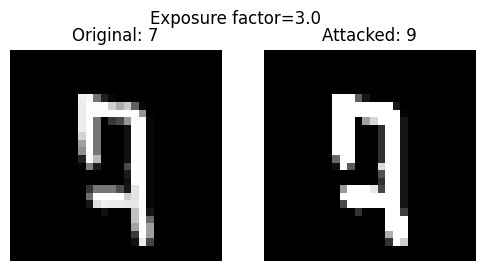

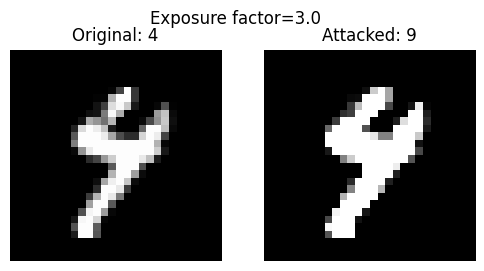

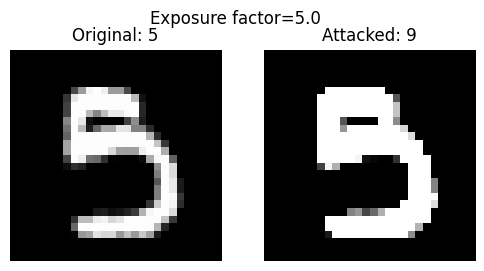

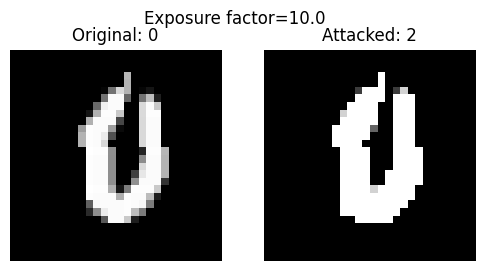

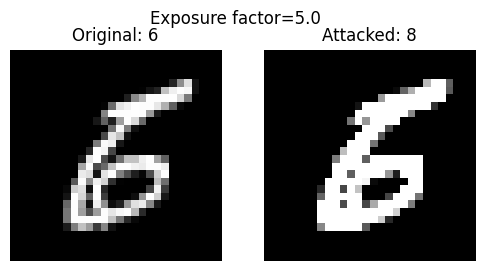

In [91]:
def show_exposure_attack(original, attacked, true_label, adv_label, factor):
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    ax[0].imshow(original.squeeze(), cmap="gray")
    ax[0].set_title(f"Original: {true_label}")
    ax[0].axis("off")

    ax[1].imshow(attacked.squeeze(), cmap="gray")
    ax[1].set_title(f"Attacked: {adv_label}")
    ax[1].axis("off")

    plt.suptitle(f"Exposure factor={factor}")
    plt.show()

for orig, adv, y_true, y_adv, factor in successful_exposure_attacks:
    show_exposure_attack(orig, adv, y_true, y_adv, factor)

In [ ]:
import os
from PIL import Image
import numpy as np

# Create directory to save exposure attack images
save_dir = "mnist/exposure_attack/successful_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save each successful exposure attack
for idx, (orig, adv, y_true, y_adv, factor) in enumerate(successful_exposure_attacks):
    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (adv.squeeze().numpy() * 255).astype(np.uint8)

    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    # Save images
    orig_img.save(f"{save_dir}/exposure_attack_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir}/exposure_attack_{idx}_attacked_pred{y_adv}_factor{factor}.png")

    print(f"Saved exposure attack {idx}: {y_true} -> {y_adv} (factor={factor})")

print(f"\nAll {len(successful_exposure_attacks)} exposure attacks saved to '{save_dir}' directory")

In [ ]:
# Create directory to save failed exposure attack images
save_dir_failed = "mnist/exposure_attack/failed_attacks_images"
os.makedirs(save_dir_failed, exist_ok=True)

# Save first 10 failed exposure attacks
for idx, (orig, attacked, y_true, y_pred, factor) in enumerate(failed_exposure_attacks[:10]):
    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (attacked.squeeze().numpy() * 255).astype(np.uint8)

    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    # Save images
    orig_img.save(f"{save_dir_failed}/failed_exposure_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir_failed}/failed_exposure_{idx}_attacked_pred{y_pred}_factor{factor}.png")

    print(f"Saved failed exposure attack {idx}: true {y_true}, pred {y_pred}, factor={factor}")

print(f"\nAll {min(10, len(failed_exposure_attacks))} failed exposure attacks saved to '{save_dir_failed}' directory")

### Mirror Attack

In [92]:
import random
from torchvision.transforms import functional as TF

def mirror_attack(model, image, label, device, num_trials=10):
    """
    image: shape (1, 1, 28, 28), values in [0,1]
    label: int
    Tries horizontal and vertical flips to fool the classifier.
    """
    model.eval()
    image = image.clone().to(device)
    label = torch.tensor([label]).to(device)

    # Original prediction
    with torch.no_grad():
        orig_pred = model(image).argmax(dim=1).item()

    if orig_pred != label.item():
        return None  # already misclassified

    flip_options = ["horizontal", "vertical"]

    for _ in range(num_trials):
        direction = random.choice(flip_options)

        if direction == "horizontal":
            flipped = TF.hflip(image)
        else:
            flipped = TF.vflip(image)

        with torch.no_grad():
            pred = model(flipped).argmax(dim=1).item()

        if pred != label.item():
            return flipped.cpu(), direction, pred

    # If no successful attack, return the last attempted flip
    return flipped.cpu(), direction, pred


In [93]:
successful_mirror_attacks = []
failed_mirror_attacks = []

for i in range(800):  # try 800 test images
    img = torch.tensor(XCnn_test[i:i+1], dtype=torch.float32)
    label = y_test[i]

    result = mirror_attack(
        cnn.module_,
        img,
        label,
        device,
        num_trials=10
    )

    if result is not None:
        attacked_img, direction, new_label = result
        if new_label != label:
            successful_mirror_attacks.append((img, attacked_img, label, new_label, direction))
        else:
            failed_mirror_attacks.append((img, attacked_img, label, new_label, direction))

    if len(successful_mirror_attacks) >= 10:
        break

print(f"Found {len(successful_mirror_attacks)} successful mirror attacks")
print(f"Found {len(failed_mirror_attacks)} failed mirror attempts")


Found 10 successful mirror attacks
Found 5 failed mirror attempts


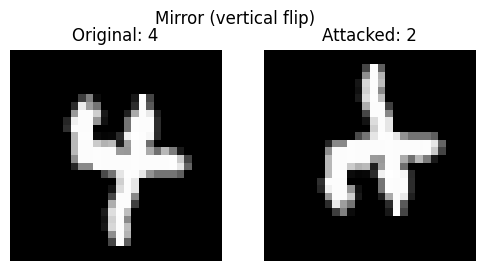

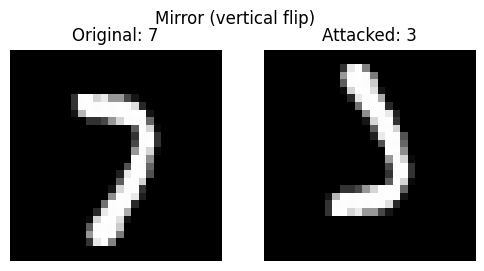

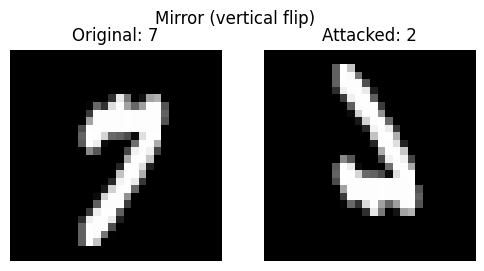

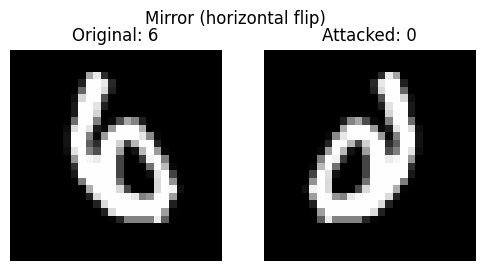

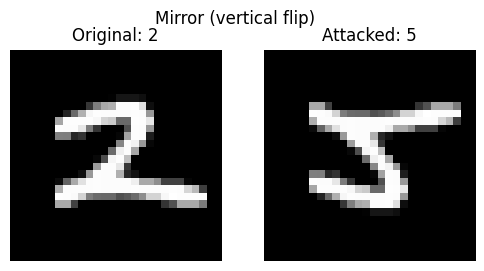

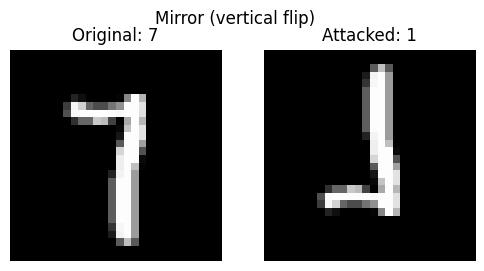

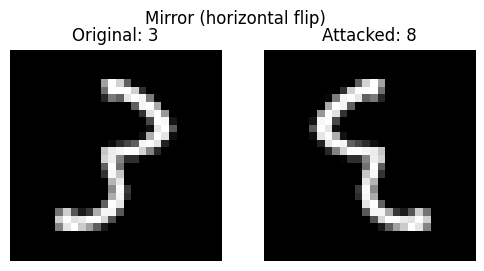

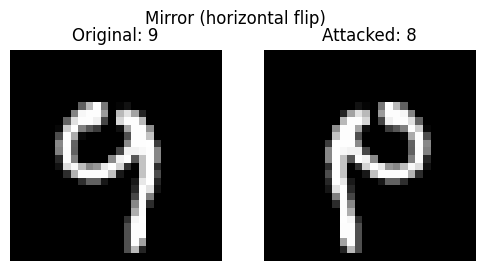

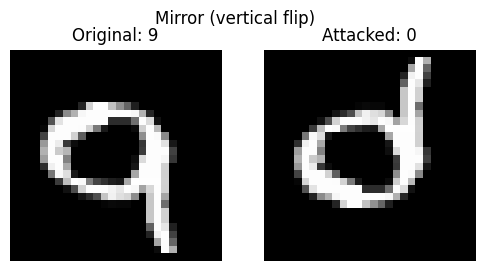

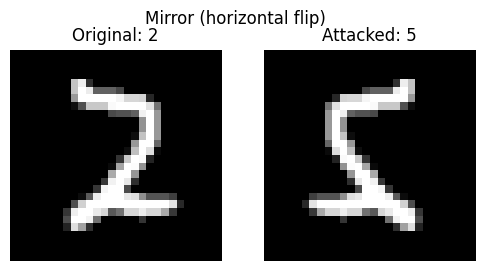

In [94]:
def show_mirror_attack(original, attacked, true_label, adv_label, direction):
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    ax[0].imshow(original.squeeze(), cmap="gray")
    ax[0].set_title(f"Original: {true_label}")
    ax[0].axis("off")

    ax[1].imshow(attacked.squeeze(), cmap="gray")
    ax[1].set_title(f"Attacked: {adv_label}")
    ax[1].axis("off")

    plt.suptitle(f"Mirror ({direction} flip)")
    plt.show()

for orig, adv, y_true, y_adv, direction in successful_mirror_attacks:
    show_mirror_attack(orig, adv, y_true, y_adv, direction)


In [95]:
import os
from PIL import Image
import numpy as np

# Create directory to save mirror attack images
save_dir = "mnist/mirror_attack/successful_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save each successful mirror attack
for idx, (orig, adv, y_true, y_adv, direction) in enumerate(successful_mirror_attacks):
    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (adv.squeeze().numpy() * 255).astype(np.uint8)

    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    # Save images
    orig_img.save(f"{save_dir}/mirror_attack_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir}/mirror_attack_{idx}_attacked_pred{y_adv}_{direction}.png")

    print(f"Saved mirror attack {idx}: {y_true} → {y_adv} ({direction} flip)")

print(f"\nAll {len(successful_mirror_attacks)} mirror attacks saved to '{save_dir}' directory")


Saved mirror attack 0: 4 → 2 (vertical flip)
Saved mirror attack 1: 7 → 3 (vertical flip)
Saved mirror attack 2: 7 → 2 (vertical flip)
Saved mirror attack 3: 6 → 0 (horizontal flip)
Saved mirror attack 4: 2 → 5 (vertical flip)
Saved mirror attack 5: 7 → 1 (vertical flip)
Saved mirror attack 6: 3 → 8 (horizontal flip)
Saved mirror attack 7: 9 → 8 (horizontal flip)
Saved mirror attack 8: 9 → 0 (vertical flip)
Saved mirror attack 9: 2 → 5 (horizontal flip)

All 10 mirror attacks saved to 'mnist/mirror_attack/successful_attacks_images' directory


In [96]:
# Create directory to save failed mirror attack images
save_dir_failed = "mnist/mirror_attack/failed_attacks_images"
os.makedirs(save_dir_failed, exist_ok=True)

# Save first 10 failed mirror attacks
for idx, (orig, attacked, y_true, y_pred, direction) in enumerate(failed_mirror_attacks[:10]):
    # Convert tensors to numpy and scale to 0-255
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (attacked.squeeze().numpy() * 255).astype(np.uint8)

    # Create PIL images
    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    # Save images
    orig_img.save(f"{save_dir_failed}/failed_mirror_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir_failed}/failed_mirror_{idx}_attacked_pred{y_pred}_{direction}.png")

    print(f"Saved failed mirror attack {idx}: true {y_true}, pred {y_pred}, {direction} flip")

print(f"\nAll {min(10, len(failed_mirror_attacks))} failed mirror attacks saved to '{save_dir_failed}' directory")


Saved failed mirror attack 0: true 8, pred 8, vertical flip
Saved failed mirror attack 1: true 8, pred 8, vertical flip
Saved failed mirror attack 2: true 0, pred 0, vertical flip
Saved failed mirror attack 3: true 4, pred 4, horizontal flip
Saved failed mirror attack 4: true 8, pred 8, vertical flip

All 5 failed mirror attacks saved to 'mnist/mirror_attack/failed_attacks_images' directory


### Emoji Attack

In [97]:
import os
import random
from PIL import Image, ImageDraw
import numpy as np

emoji_path = "mnist/emoji.png"
emoji_size = 8

# Use a provided emoji image if available; otherwise generate a simple fallback icon.
if os.path.isfile(emoji_path):
    emoji_img = Image.open(emoji_path).convert("L").resize((emoji_size, emoji_size))
else:
    emoji_img = Image.new("L", (emoji_size, emoji_size), color=255)
    draw = ImageDraw.Draw(emoji_img)
    draw.ellipse((0, 0, emoji_size - 1, emoji_size - 1), fill=180)
    draw.ellipse((2, 2, 2, 2), fill=0)
    draw.ellipse((5, 2, 5, 2), fill=0)
    draw.arc((2, 2, 5, 6), start=20, end=160, fill=0)

emoji_arr = np.array(emoji_img, dtype=np.float32) / 255.0
emoji_patch = torch.from_numpy(emoji_arr).unsqueeze(0).unsqueeze(0)

def emoji_attack(model, image, label, device, emoji, num_trials=50):
    """
    image: shape (1, 1, 28, 28), values in [0,1]
    label: int
    """
    model.eval()
    image = image.clone().to(device)
    label = torch.tensor([label]).to(device)
    emoji = emoji.to(device)

    with torch.no_grad():
        orig_pred = model(image).argmax(dim=1).item()

    if orig_pred != label.item():
        return None  # already misclassified

    attacked = image.clone()
    emoji_info = None
    pred = orig_pred

    ph, pw = emoji.shape[-2], emoji.shape[-1]

    for _ in range(num_trials):
        attacked = image.clone()

        x = random.randint(0, 28 - ph)
        y = random.randint(0, 28 - pw)

        # Alpha-like blend so the emoji is visible while preserving image structure.
        region = attacked[0, 0, x:x + ph, y:y + pw]
        attacked[0, 0, x:x + ph, y:y + pw] = torch.clamp(0.5 * region + 0.5 * emoji[0, 0], 0.0, 1.0)

        with torch.no_grad():
            pred = model(attacked).argmax(dim=1).item()

        emoji_info = (x, y, ph, pw)

        if pred != label.item():
            return attacked.cpu(), emoji_info, pred

    return attacked.cpu(), emoji_info, pred

In [98]:
successful_emoji_attacks = []
failed_emoji_attacks = []

for i in range(800):  # try 800 test images
    img = torch.tensor(XCnn_test[i:i+1], dtype=torch.float32)
    label = y_test[i]

    result = emoji_attack(
        cnn.module_,
        img,
        label,
        device,
        emoji_patch,
        num_trials=100,
    )

    if result is not None:
        attacked_img, emoji_info, new_label = result
        if new_label != label:
            successful_emoji_attacks.append((img, attacked_img, label, new_label, emoji_info))
        else:
            failed_emoji_attacks.append((img, attacked_img, label, new_label, emoji_info))

    if len(successful_emoji_attacks) >= 10:
        break

print(f"Found {len(successful_emoji_attacks)} successful emoji attacks")
print(f"Found {len(failed_emoji_attacks)} failed emoji attempts")

Found 10 successful emoji attacks
Found 200 failed emoji attempts


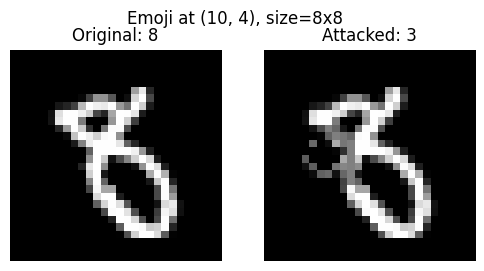

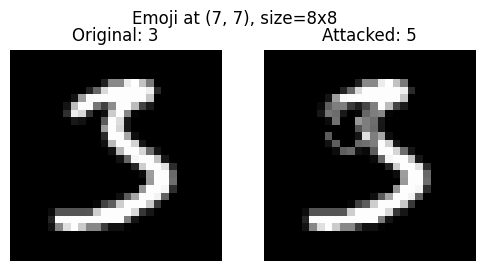

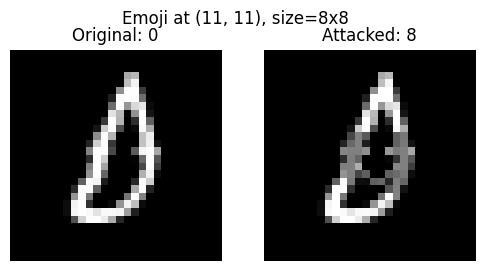

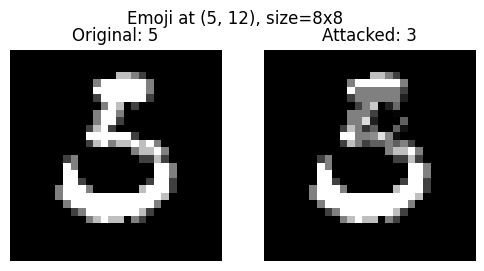

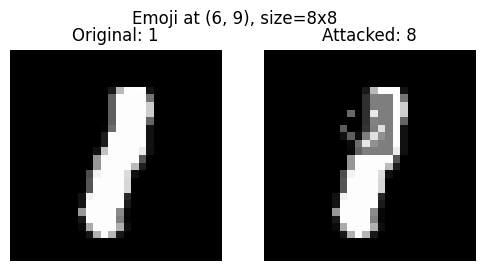

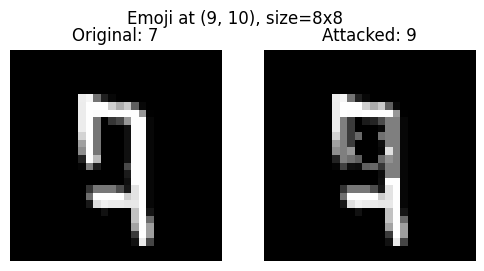

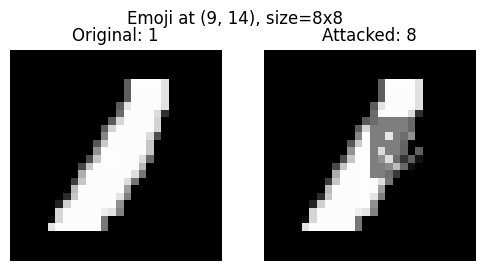

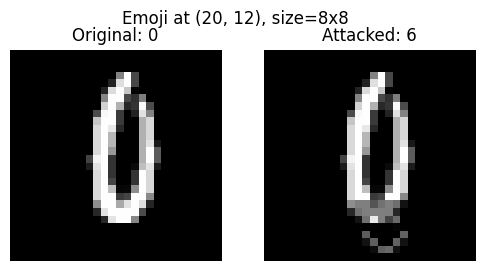

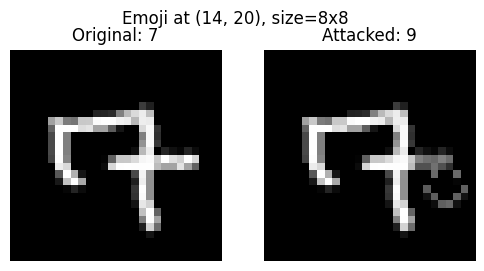

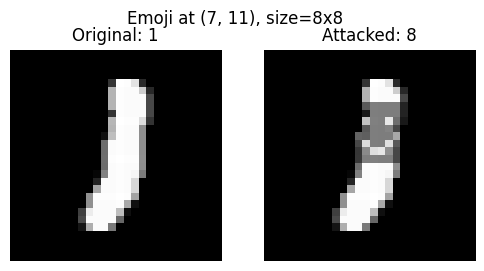

In [99]:
def show_emoji_attack(original, attacked, true_label, adv_label, info):
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    ax[0].imshow(original.squeeze(), cmap="gray")
    ax[0].set_title(f"Original: {true_label}")
    ax[0].axis("off")

    ax[1].imshow(attacked.squeeze(), cmap="gray")
    ax[1].set_title(f"Attacked: {adv_label}")
    ax[1].axis("off")

    x, y, ph, pw = info
    plt.suptitle(f"Emoji at ({x}, {y}), size={ph}x{pw}")
    plt.show()

for orig, adv, y_true, y_adv, info in successful_emoji_attacks:
    show_emoji_attack(orig, adv, y_true, y_adv, info)

In [100]:
# Create directory to save emoji attack images
save_dir = "mnist/emoji_attack/successful_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save each successful emoji attack
for idx, (orig, adv, y_true, y_adv, info) in enumerate(successful_emoji_attacks):
    x, y, ph, pw = info
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (adv.squeeze().numpy() * 255).astype(np.uint8)

    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    orig_img.save(f"{save_dir}/emoji_attack_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir}/emoji_attack_{idx}_attacked_pred{y_adv}_x{x}_y{y}_h{ph}_w{pw}.png")

    print(f"Saved emoji attack {idx}: {y_true} -> {y_adv} (x={x}, y={y}, h={ph}, w={pw})")

print(f"\nAll {len(successful_emoji_attacks)} emoji attacks saved to '{save_dir}' directory")

Saved emoji attack 0: 8 -> 3 (x=10, y=4, h=8, w=8)
Saved emoji attack 1: 3 -> 5 (x=7, y=7, h=8, w=8)
Saved emoji attack 2: 0 -> 8 (x=11, y=11, h=8, w=8)
Saved emoji attack 3: 5 -> 3 (x=5, y=12, h=8, w=8)
Saved emoji attack 4: 1 -> 8 (x=6, y=9, h=8, w=8)
Saved emoji attack 5: 7 -> 9 (x=9, y=10, h=8, w=8)
Saved emoji attack 6: 1 -> 8 (x=9, y=14, h=8, w=8)
Saved emoji attack 7: 0 -> 6 (x=20, y=12, h=8, w=8)
Saved emoji attack 8: 7 -> 9 (x=14, y=20, h=8, w=8)
Saved emoji attack 9: 1 -> 8 (x=7, y=11, h=8, w=8)

All 10 emoji attacks saved to 'mnist/emoji_attack/successful_attacks_images' directory


In [101]:
# Create directory to save failed emoji attack images
save_dir_failed = "mnist/emoji_attack/failed_attacks_images"
os.makedirs(save_dir_failed, exist_ok=True)

# Save first 10 failed emoji attacks
for idx, (orig, attacked, y_true, y_pred, info) in enumerate(failed_emoji_attacks[:10]):
    x, y, ph, pw = info
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (attacked.squeeze().numpy() * 255).astype(np.uint8)

    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    orig_img.save(f"{save_dir_failed}/failed_emoji_{idx}_original_true{y_true}.png")
    adv_img.save(f"{save_dir_failed}/failed_emoji_{idx}_attacked_pred{y_pred}_x{x}_y{y}_h{ph}_w{pw}.png")

    print(f"Saved failed emoji attack {idx}: true {y_true}, pred {y_pred}, x={x}, y={y}, h={ph}, w={pw}")

print(f"\nAll {min(10, len(failed_emoji_attacks))} failed emoji attacks saved to '{save_dir_failed}' directory")

Saved failed emoji attack 0: true 8, pred 8, x=4, y=1, h=8, w=8
Saved failed emoji attack 1: true 4, pred 4, x=18, y=3, h=8, w=8
Saved failed emoji attack 2: true 7, pred 7, x=6, y=12, h=8, w=8
Saved failed emoji attack 3: true 7, pred 7, x=3, y=15, h=8, w=8
Saved failed emoji attack 4: true 0, pred 0, x=12, y=11, h=8, w=8
Saved failed emoji attack 5: true 6, pred 6, x=13, y=10, h=8, w=8
Saved failed emoji attack 6: true 2, pred 2, x=18, y=10, h=8, w=8
Saved failed emoji attack 7: true 7, pred 7, x=13, y=7, h=8, w=8
Saved failed emoji attack 8: true 4, pred 4, x=13, y=6, h=8, w=8
Saved failed emoji attack 9: true 3, pred 3, x=14, y=9, h=8, w=8

All 10 failed emoji attacks saved to 'mnist/emoji_attack/failed_attacks_images' directory


### Black Line Attack

In [102]:
import random

def black_line_attack(model, image, label, device, num_trials=50):
    """
    Add a 1-pixel-thick black horizontal or vertical line at a random position.
    image: shape (1, 1, 28, 28), values in [0,1]
    label: int
    """
    model.eval()
    image = image.clone().to(device)
    label = torch.tensor([label]).to(device)

    with torch.no_grad():
        orig_pred = model(image).argmax(dim=1).item()

    if orig_pred != label.item():
        return None  # already misclassified

    attacked = image.clone()
    line_info = None
    pred = orig_pred

    line_lengths = [8, 12, 16, 20, 24, 28]

    for _ in range(num_trials):
        attacked = image.clone()
        orientation = random.choice(["horizontal", "vertical"])
        line_len = random.choice(line_lengths)

        if orientation == "horizontal":
            row = random.randint(0, 27)
            start_col = random.randint(0, 28 - line_len)
            attacked[0, 0, row, start_col:start_col + line_len] = 0.0
            line_info = (orientation, row, start_col, line_len)
        else:
            col = random.randint(0, 27)
            start_row = random.randint(0, 28 - line_len)
            attacked[0, 0, start_row:start_row + line_len, col] = 0.0
            line_info = (orientation, col, start_row, line_len)

        with torch.no_grad():
            pred = model(attacked).argmax(dim=1).item()

        if pred != label.item():
            return attacked.cpu(), line_info, pred

    return attacked.cpu(), line_info, pred

In [103]:
successful_black_line_attacks = []
failed_black_line_attacks = []

for i in range(800):  # try 800 test images
    img = torch.tensor(XCnn_test[i:i+1], dtype=torch.float32)
    label = y_test[i]

    result = black_line_attack(
        cnn.module_,
        img,
        label,
        device,
        num_trials=100,
    )

    if result is not None:
        attacked_img, line_info, new_label = result
        if new_label != label:
            successful_black_line_attacks.append((img, attacked_img, label, new_label, line_info))
        else:
            failed_black_line_attacks.append((img, attacked_img, label, new_label, line_info))

    if len(successful_black_line_attacks) >= 10:
        break

print(f"Found {len(successful_black_line_attacks)} successful black line attacks")
print(f"Found {len(failed_black_line_attacks)} failed black line attempts")

Found 10 successful black line attacks
Found 272 failed black line attempts


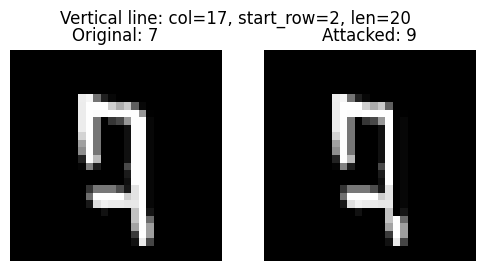

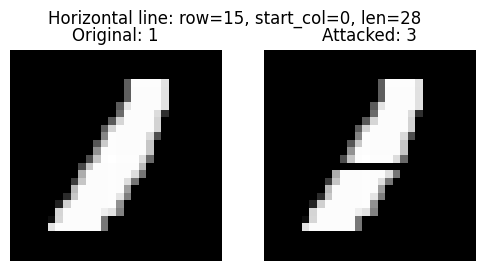

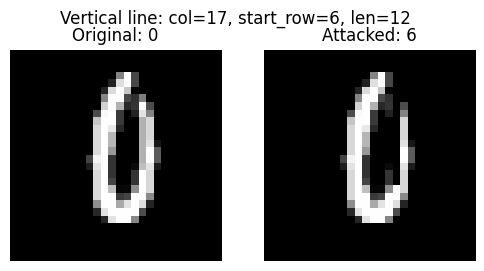

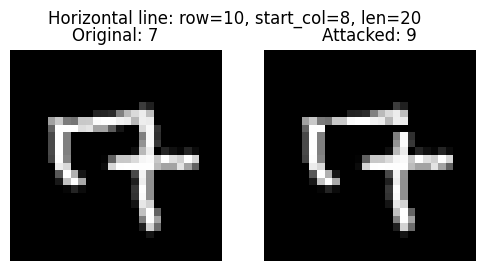

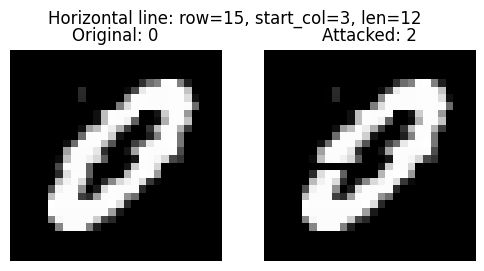

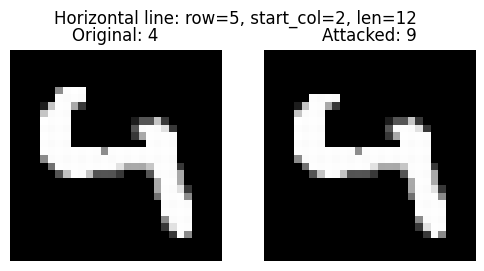

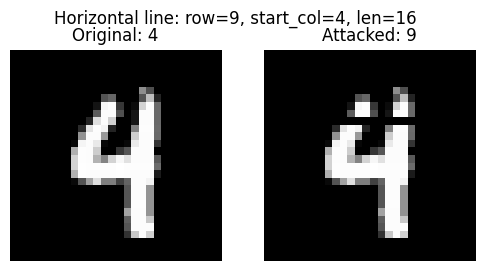

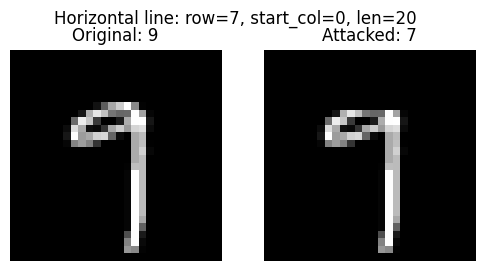

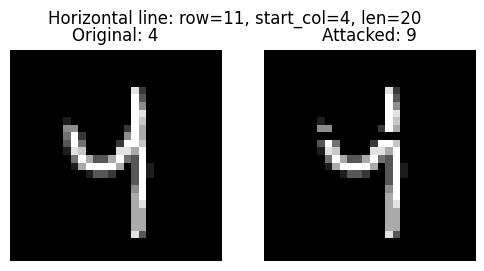

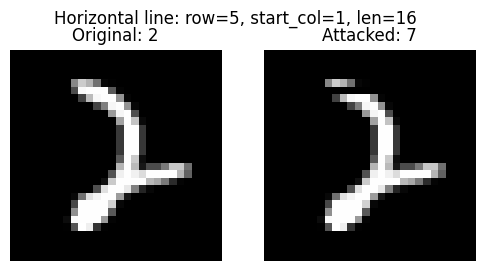

In [104]:
def show_black_line_attack(original, attacked, true_label, adv_label, line_info):
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    ax[0].imshow(original.squeeze(), cmap="gray")
    ax[0].set_title(f"Original: {true_label}")
    ax[0].axis("off")

    ax[1].imshow(attacked.squeeze(), cmap="gray")
    ax[1].set_title(f"Attacked: {adv_label}")
    ax[1].axis("off")

    orientation, fixed, start, line_len = line_info
    if orientation == "horizontal":
        desc = f"Horizontal line: row={fixed}, start_col={start}, len={line_len}"
    else:
        desc = f"Vertical line: col={fixed}, start_row={start}, len={line_len}"
    plt.suptitle(desc)
    plt.show()

for orig, adv, y_true, y_adv, info in successful_black_line_attacks:
    show_black_line_attack(orig, adv, y_true, y_adv, info)

In [105]:
import os
from PIL import Image
import numpy as np

# Create directory to save successful black line attack images
save_dir = "mnist/black_line_attack/successful_attacks_images"
os.makedirs(save_dir, exist_ok=True)

# Save each successful black line attack
for idx, (orig, adv, y_true, y_adv, info) in enumerate(successful_black_line_attacks):
    orientation, fixed, start, line_len = info
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (adv.squeeze().numpy() * 255).astype(np.uint8)

    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    orig_img.save(f"{save_dir}/black_line_{idx}_original_true{y_true}.png")
    adv_img.save(
        f"{save_dir}/black_line_{idx}_attacked_pred{y_adv}_{orientation}_fixed{fixed}_start{start}_len{line_len}.png"
    )

    print(f"Saved black line attack {idx}: {y_true} -> {y_adv} ({orientation}, len={line_len})")

print(f"\nAll {len(successful_black_line_attacks)} successful black line attacks saved to '{save_dir}' directory")

Saved black line attack 0: 7 -> 9 (vertical, len=20)
Saved black line attack 1: 1 -> 3 (horizontal, len=28)
Saved black line attack 2: 0 -> 6 (vertical, len=12)
Saved black line attack 3: 7 -> 9 (horizontal, len=20)
Saved black line attack 4: 0 -> 2 (horizontal, len=12)
Saved black line attack 5: 4 -> 9 (horizontal, len=12)
Saved black line attack 6: 4 -> 9 (horizontal, len=16)
Saved black line attack 7: 9 -> 7 (horizontal, len=20)
Saved black line attack 8: 4 -> 9 (horizontal, len=20)
Saved black line attack 9: 2 -> 7 (horizontal, len=16)

All 10 successful black line attacks saved to 'mnist/black_line_attack/successful_attacks_images' directory


In [106]:
# Create directory to save failed black line attack images
save_dir_failed = "mnist/black_line_attack/failed_attacks_images"
os.makedirs(save_dir_failed, exist_ok=True)

# Save first 10 failed black line attacks
for idx, (orig, attacked, y_true, y_pred, info) in enumerate(failed_black_line_attacks[:10]):
    orientation, fixed, start, line_len = info
    orig_np = (orig.squeeze().numpy() * 255).astype(np.uint8)
    adv_np = (attacked.squeeze().numpy() * 255).astype(np.uint8)

    orig_img = Image.fromarray(orig_np)
    adv_img = Image.fromarray(adv_np)

    orig_img.save(f"{save_dir_failed}/failed_black_line_{idx}_original_true{y_true}.png")
    adv_img.save(
        f"{save_dir_failed}/failed_black_line_{idx}_attacked_pred{y_pred}_{orientation}_fixed{fixed}_start{start}_len{line_len}.png"
    )

    print(f"Saved failed black line attack {idx}: true {y_true}, pred {y_pred}, {orientation}, len={line_len}")

print(f"\nAll {min(10, len(failed_black_line_attacks))} failed black line attacks saved to '{save_dir_failed}' directory")

Saved failed black line attack 0: true 8, pred 8, vertical, len=12
Saved failed black line attack 1: true 4, pred 4, horizontal, len=12
Saved failed black line attack 2: true 8, pred 8, vertical, len=16
Saved failed black line attack 3: true 7, pred 7, horizontal, len=24
Saved failed black line attack 4: true 7, pred 7, vertical, len=24
Saved failed black line attack 5: true 0, pred 0, vertical, len=24
Saved failed black line attack 6: true 6, pred 6, horizontal, len=12
Saved failed black line attack 7: true 2, pred 2, vertical, len=24
Saved failed black line attack 8: true 7, pred 7, vertical, len=28
Saved failed black line attack 9: true 4, pred 4, vertical, len=20

All 10 failed black line attacks saved to 'mnist/black_line_attack/failed_attacks_images' directory
